In [1]:
import sys
import pandas as pd
import numpy as np
import pyarrow
import sklearn
import xgboost

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("PyArrow:", pyarrow.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

Python: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.6
NumPy: 2.5.3
PyArrow: 25.0.1
Scikit-learn: 1.9.1
XGBoost: 3.4.1


In [2]:
import pandas as pd
import numpy as np
import duckdb
import pyarrow.parquet as pq

# File paths
STATIONS_PATH = "../data/raw/stations.parquet"
DAILY_PATH = "../data/raw/daily.parquet"
HOURLY_PATH = "../data/raw/hourly.parquet"

# DuckDB connection
con = duckdb.connect()

# Load small station metadata
stations = pd.read_parquet(STATIONS_PATH)

print("Environment ready.")
print("Stations:", stations.shape)

Rows: 34692674
Columns: ['station_code', 'datatype_code', 'variable', 'unit', 'source_type', 'date_ist', 'min', 'mean', 'max', 'sum', 'n_obs']
Row groups: 35


In [3]:
stations = pd.read_parquet(
    "../data/raw/stations.parquet"
)

print(stations.shape)

(1747, 11)


In [4]:
stations.head()

,station_code,name,lat,lon,type,nearest_town,warning_level,danger_level,frl,mwl,highest_flow_level
0,001-CDBNG,Shimoga,13.926944,75.585000,Base,NaN,566.7,567.25,NaN,NaN,570.18
1,001-CDJPR,Dhareri,23.147500,75.508333,Base,,478.5,479.50,NaN,NaN,482.62
2,001-CHEJMU,Khanabal,33.763889,75.127500,Base,Khanabal,1591.2,1592.50,NaN,NaN,1595.43
3,001-DDASL,Tilaiya Reservoir,24.320000,85.520000,Inflow,,NaN,NaN,372.475,371.465,372.28
4,001-ERDBWN,Balimundali,21.733889,86.633333,Base,NaN,NaN,NaN,NaN,NaN,43.10


In [5]:
stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 1747 entries, 0 to 1746
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   station_code        1747 non-null   str    
 1   name                1746 non-null   str    
 2   lat                 1746 non-null   float64
 3   lon                 1746 non-null   float64
 4   type                1747 non-null   str    
 5   nearest_town        755 non-null    str    
 6   warning_level       1014 non-null   float64
 7   danger_level        1035 non-null   float64
 8   frl                 149 non-null    float64
 9   mwl                 125 non-null    float64
 10  highest_flow_level  1532 non-null   float64
dtypes: float64(7), str(4)
memory usage: 194.1 KB


In [6]:
stations.describe(include="all")

,station_code,name,lat,lon,type,nearest_town,warning_level,danger_level,frl,mwl,highest_flow_level
count,1747,1746,1746.000000,1746.000000,1747,755,1014.000000,1035.000000,149.000000,125.000000,1532.000000
unique,1747,1731,NaN,NaN,3,120,NaN,NaN,NaN,NaN,NaN
top,001-CDBNG,Haripur,NaN,NaN,Base,,NaN,NaN,NaN,NaN,NaN
freq,1,2,NaN,NaN,1393,627,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,22.975986,81.677983,NaN,NaN,295.956255,293.050503,329.522067,261.247552,301.708037
std,NaN,NaN,5.710555,5.898870,NaN,NaN,446.794072,443.360262,223.745561,182.619810,471.500335
min,NaN,NaN,8.158333,68.768333,NaN,NaN,2.500000,3.400000,10.760000,0.000000,3.600000
25%,NaN,NaN,20.015278,77.154931,NaN,NaN,58.785000,57.822500,138.000000,103.950000,57.315000
50%,NaN,NaN,24.121944,79.977639,NaN,NaN,145.695000,143.000000,279.200000,242.620000,154.815000
75%,NaN,NaN,26.646597,85.833681,NaN,NaN,350.500000,346.860000,490.000000,371.465000,336.205000


In [7]:
stations[[
    "station_code",
    "name",
    "lat",
    "lon",
    "type",
    "warning_level",
    "danger_level"
]].head(20)

,station_code,name,lat,lon,type,warning_level,danger_level
0,001-CDBNG,Shimoga,13.926944,75.585000,Base,566.700,567.250
1,001-CDJPR,Dhareri,23.147500,75.508333,Base,478.500,479.500
2,001-CHEJMU,Khanabal,33.763889,75.127500,Base,1591.200,1592.500
3,001-DDASL,Tilaiya Reservoir,24.320000,85.520000,Inflow,NaN,NaN
4,001-ERDBWN,Balimundali,21.733889,86.633333,Base,NaN,NaN
5,001-HGDDDN,Badrinath,30.748333,79.495833,Base,3112.000,3113.000
6,001-HYDCHENNAI,Chennur,14.572222,78.800000,Base,121.875,122.875
7,001-LBDJPG,Mathanguri,26.782778,90.956667,Level,98.100,99.100
8,001-LGD3BEH,BEDEPARA,24.139167,88.696944,Base,NaN,NaN
9,001-LGDHYD,Somanpally(Seasonal),18.616667,79.800000,Base,NaN,NaN


In [8]:
stations["type"].value_counts(dropna=False)

type
Base      1393
Level      208
Inflow     146
Name: count, dtype: int64

In [9]:
print(
    "Warning level:",
    stations["warning_level"].notna().sum()
)

print(
    "Danger level:",
    stations["danger_level"].notna().sum()
)

Warning level: 1014
Danger level: 1035


In [10]:
print(
    stations[
        ["lat", "lon"]
    ].describe()
)

               lat          lon
count  1746.000000  1746.000000
mean     22.975986    81.677983
std       5.710555     5.898870
min       8.158333    68.768333
25%      20.015278    77.154931
50%      24.121944    79.977639
75%      26.646597    85.833681
max      34.603611    97.025833


In [11]:
print(
    "Missing latitude:",
    stations["lat"].isna().sum()
)

print(
    "Missing longitude:",
    stations["lon"].isna().sum()
)

Missing latitude: 1
Missing longitude: 1


In [12]:
daily_sample = pd.read_parquet(
    "../data/raw/daily.parquet",
    columns=[
        "station_code",
        "datatype_code",
        "variable",
        "unit",
        "date_ist",
        "min",
        "mean",
        "max",
        "sum",
        "n_obs",
        "source_type"
    ],
    engine="pyarrow"
)

In [13]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("../data/raw/daily.parquet")

print(pf.schema_arrow)

station_code: large_string
datatype_code: large_string
variable: large_string
unit: large_string
source_type: large_string
date_ist: date32[day]
min: double
mean: double
max: double
sum: double
n_obs: uint32


In [14]:
table = pf.read_row_group(
    0,
    columns=[
        "station_code",
        "datatype_code",
        "variable",
        "unit",
        "date_ist",
        "min",
        "mean",
        "max",
        "sum",
        "n_obs",
        "source_type"
    ]
)

sample = table.to_pandas()

sample.head()

,station_code,datatype_code,variable,unit,date_ist,min,mean,max,sum,n_obs,source_type
0,001-CDBNG,BAT,bat,NaN,2021-03-03,10.0,10.000000,10.0,10.0,1,gauge
1,001-CDBNG,BAT,bat,NaN,2021-03-04,10.0,10.000000,10.0,10.0,1,gauge
2,001-CDBNG,BAT,bat,NaN,2021-03-05,10.1,13.166667,18.8,39.5,3,gauge
3,001-CDBNG,BAT,bat,NaN,2021-03-06,10.8,10.866667,11.0,32.6,3,gauge
4,001-CDBNG,BAT,bat,NaN,2021-03-07,10.1,12.800000,19.5,51.2,4,gauge


In [15]:
sample.shape

(1000000, 11)

In [16]:
sample["variable"].value_counts(dropna=False)

variable
water_level          393750
rainfall             228543
air_temp_max          94089
air_temp_min          93746
water_temp            47769
mhs                   19264
air_temp              18387
reservoir_percent     14591
mws                   14480
hq2                   12515
mwi                   10864
bat                    8893
discharge              8355
reservoir_outflow      7928
reservoir_inflow       7487
mw1                    5104
mep                    4721
mtp                    4660
mw2                    2219
mhh                     822
mpt                     607
mha                     579
str                     390
mod                     234
qwq                       3
Name: count, dtype: int64

In [17]:
sample["datatype_code"].value_counts()

datatype_code
HHS    267642
MPS    189254
HZS    107080
MTX     94089
MTN     93746
HTW     30129
MPM     21941
MHS     19264
HHT     19027
MTD     18387
MTW     17640
MPA     17348
IPC     14591
MWS     14480
HQ2     12515
MWI     10864
BAT      8893
HQ0      8355
FIN      7487
FOL      6247
MW1      5104
MEP      4721
MTP      4660
MW2      2219
FOU      1681
MHH       822
MPT       607
MHA       579
STR       390
MOD       234
QWQ         3
HZF         1
Name: count, dtype: int64

In [18]:
sample["variable"].value_counts(dropna=False)

variable
water_level          393750
rainfall             228543
air_temp_max          94089
air_temp_min          93746
water_temp            47769
mhs                   19264
air_temp              18387
reservoir_percent     14591
mws                   14480
hq2                   12515
mwi                   10864
bat                    8893
discharge              8355
reservoir_outflow      7928
reservoir_inflow       7487
mw1                    5104
mep                    4721
mtp                    4660
mw2                    2219
mhh                     822
mpt                     607
mha                     579
str                     390
mod                     234
qwq                       3
Name: count, dtype: int64

In [19]:
import pyarrow.parquet as pq

stations_path = "../data/raw/stations.parquet"
daily_path = "../data/raw/daily.parquet"
hourly_path = "../data/raw/hourly.parquet"

for name, path in [
    ("stations", stations_path),
    ("daily", daily_path),
    ("hourly", hourly_path),
]:
    pf = pq.ParquetFile(path)

    print(f"\n{name.upper()}")
    print("-" * 50)
    print("Rows:", pf.metadata.num_rows)
    print("Columns:", pf.schema.names)
    print("Row groups:", pf.num_row_groups)


STATIONS
--------------------------------------------------
Rows: 1747
Columns: ['station_code', 'name', 'lat', 'lon', 'type', 'nearest_town', 'warning_level', 'danger_level', 'frl', 'mwl', 'highest_flow_level']
Row groups: 1

DAILY
--------------------------------------------------
Rows: 34692674
Columns: ['station_code', 'datatype_code', 'variable', 'unit', 'source_type', 'date_ist', 'min', 'mean', 'max', 'sum', 'n_obs']
Row groups: 35

HOURLY
--------------------------------------------------
Rows: 58405209
Columns: ['station_code', 'station_code_raw', 'datetime', 'datatype_code', 'variable', 'unit', 'value', 'source_type']
Row groups: 59


In [20]:
stations = pd.read_parquet(stations_path)

print("Shape:", stations.shape)
display(stations.head())

Shape: (1747, 11)


,station_code,name,lat,lon,type,nearest_town,warning_level,danger_level,frl,mwl,highest_flow_level
0,001-CDBNG,Shimoga,13.926944,75.585000,Base,NaN,566.7,567.25,NaN,NaN,570.18
1,001-CDJPR,Dhareri,23.147500,75.508333,Base,,478.5,479.50,NaN,NaN,482.62
2,001-CHEJMU,Khanabal,33.763889,75.127500,Base,Khanabal,1591.2,1592.50,NaN,NaN,1595.43
3,001-DDASL,Tilaiya Reservoir,24.320000,85.520000,Inflow,,NaN,NaN,372.475,371.465,372.28
4,001-ERDBWN,Balimundali,21.733889,86.633333,Base,NaN,NaN,NaN,NaN,NaN,43.10


In [21]:
print(stations["type"].value_counts(dropna=False))

type
Base      1393
Level      208
Inflow     146
Name: count, dtype: int64


In [22]:
print(stations["type"].value_counts(dropna=False))

type
Base      1393
Level      208
Inflow     146
Name: count, dtype: int64


In [23]:
pf = pq.ParquetFile(daily_path)

table = pf.read_row_group(
    0,
    columns=[
        "station_code",
        "datatype_code",
        "variable",
        "unit",
        "date_ist",
        "min",
        "mean",
        "max",
        "sum",
        "n_obs",
        "source_type"
    ]
)

sample = table.to_pandas()

print("Sample shape:", sample.shape)
display(sample.head())

Sample shape: (1000000, 11)


,station_code,datatype_code,variable,unit,date_ist,min,mean,max,sum,n_obs,source_type
0,001-CDBNG,BAT,bat,NaN,2021-03-03,10.0,10.000000,10.0,10.0,1,gauge
1,001-CDBNG,BAT,bat,NaN,2021-03-04,10.0,10.000000,10.0,10.0,1,gauge
2,001-CDBNG,BAT,bat,NaN,2021-03-05,10.1,13.166667,18.8,39.5,3,gauge
3,001-CDBNG,BAT,bat,NaN,2021-03-06,10.8,10.866667,11.0,32.6,3,gauge
4,001-CDBNG,BAT,bat,NaN,2021-03-07,10.1,12.800000,19.5,51.2,4,gauge


In [24]:
print(sample["variable"].value_counts(dropna=False))

variable
water_level          393750
rainfall             228543
air_temp_max          94089
air_temp_min          93746
water_temp            47769
mhs                   19264
air_temp              18387
reservoir_percent     14591
mws                   14480
hq2                   12515
mwi                   10864
bat                    8893
discharge              8355
reservoir_outflow      7928
reservoir_inflow       7487
mw1                    5104
mep                    4721
mtp                    4660
mw2                    2219
mhh                     822
mpt                     607
mha                     579
str                     390
mod                     234
qwq                       3
Name: count, dtype: int64


In [25]:
print(sample["datatype_code"].value_counts())

datatype_code
HHS    267642
MPS    189254
HZS    107080
MTX     94089
MTN     93746
HTW     30129
MPM     21941
MHS     19264
HHT     19027
MTD     18387
MTW     17640
MPA     17348
IPC     14591
MWS     14480
HQ2     12515
MWI     10864
BAT      8893
HQ0      8355
FIN      7487
FOL      6247
MW1      5104
MEP      4721
MTP      4660
MW2      2219
FOU      1681
MHH       822
MPT       607
MHA       579
STR       390
MOD       234
QWQ         3
HZF         1
Name: count, dtype: int64


In [1]:
import duckdb
import pandas as pd

con = duckdb.connect()

In [2]:
print(duckdb.__version__)

1.5.6


In [3]:
daily_path = "../data/raw/daily.parquet"

result = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        MIN(date_ist) AS earliest_date,
        MAX(date_ist) AS latest_date,
        COUNT(DISTINCT station_code) AS stations,
        COUNT(DISTINCT datatype_code) AS parameters
    FROM read_parquet('{daily_path}')
""").fetchdf()

display(result)

,total_rows,earliest_date,latest_date,stations,parameters
0,34692674,1900-06-15,2026-09-11,1654,81


In [4]:
variable_counts = con.execute(f"""
    SELECT
        variable,
        datatype_code,
        unit,
        COUNT(*) AS rows
    FROM read_parquet('{daily_path}')
    GROUP BY
        variable,
        datatype_code,
        unit
    ORDER BY rows DESC
""").fetchdf()

display(variable_counts)

,variable,datatype_code,unit,rows
0,water_level,HHS,m,8558926
1,rainfall,MPS,mm,7683511
2,air_temp_max,MTX,degC,3142502
3,air_temp_min,MTN,degC,3131023
4,water_level,HZS,m,3028113
...,...,...,...,...
76,hhy,HHY,NaN,49
77,mph,MPH,NaN,44
78,qwq,QWQ,NaN,34
79,mbs,MBS,NaN,33


In [5]:
water_level_codes = [
    "HHS",
    "HHA",
    "HHX",
    "HHT",
    "HZS",
    "HZF"
]

query = f"""
    SELECT
        datatype_code,
        variable,
        unit,
        COUNT(*) AS rows,
        COUNT(DISTINCT station_code) AS stations,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date
    FROM read_parquet('{daily_path}')
    WHERE datatype_code IN ({",".join("'" + x + "'" for x in water_level_codes)})
    GROUP BY
        datatype_code,
        variable,
        unit
    ORDER BY rows DESC
"""

water_level_summary = con.execute(query).fetchdf()

display(water_level_summary)

,datatype_code,variable,unit,rows,stations,first_date,last_date
0,HHS,water_level,m,8558926,1609,1919-06-16,2026-09-11
1,HZS,water_level,m,3028113,786,1961-01-13,2026-09-11
2,HHT,water_level,m,787352,626,1921-01-03,2026-09-10
3,HZF,water_level,m,159395,99,1969-01-21,2026-09-11
4,HHX,water_level,m,21166,17,2000-01-01,2017-10-30
5,HHA,water_level,m,1249,2,2012-06-01,2019-10-01


In [6]:
rainfall_codes = [
    "MPS",
    "MPA",
    "MPM",
    "MPN"
]

query = f"""
    SELECT
        datatype_code,
        variable,
        unit,
        COUNT(*) AS rows,
        COUNT(DISTINCT station_code) AS stations,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date
    FROM read_parquet('{daily_path}')
    WHERE datatype_code IN ({",".join("'" + x + "'" for x in rainfall_codes)})
    GROUP BY
        datatype_code,
        variable,
        unit
    ORDER BY rows DESC
"""

rainfall_summary = con.execute(query).fetchdf()

display(rainfall_summary)

,datatype_code,variable,unit,rows,stations,first_date,last_date
0,MPS,rainfall,mm,7683511,1549,1960-05-01,2026-09-11
1,MPM,rainfall,mm,817793,641,1900-06-15,2026-09-10
2,MPA,rainfall,mm,367135,123,1964-06-01,2026-02-28
3,MPN,rainfall,mm,3120,4,1995-03-01,2015-12-30


In [7]:
query = f"""
    SELECT
        datatype_code,
        variable,
        unit,
        COUNT(*) AS rows,
        COUNT(DISTINCT station_code) AS stations,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date
    FROM read_parquet('{daily_path}')
    WHERE datatype_code = 'HQ0'
    GROUP BY
        datatype_code,
        variable,
        unit
"""

discharge_summary = con.execute(query).fetchdf()

display(discharge_summary)

,datatype_code,variable,unit,rows,stations,first_date,last_date
0,HQ0,discharge,cumec,442734,137,1962-07-04,2026-09-10


In [8]:
station_variables = con.execute(f"""
    SELECT
        station_code,

        MAX(
            CASE
                WHEN datatype_code IN ('HHS','HHA','HHX','HHT','HZS','HZF')
                THEN 1 ELSE 0
            END
        ) AS has_water_level,

        MAX(
            CASE
                WHEN datatype_code IN ('MPS','MPA','MPM','MPN')
                THEN 1 ELSE 0
            END
        ) AS has_rainfall,

        MAX(
            CASE
                WHEN datatype_code = 'HQ0'
                THEN 1 ELSE 0
            END
        ) AS has_discharge

    FROM read_parquet('{daily_path}')
    GROUP BY station_code
    ORDER BY station_code
""").fetchdf()

display(station_variables.head(20))

,station_code,has_water_level,has_rainfall,has_discharge
0,001-CDBNG,1,1,0
1,001-CDJPR,1,1,0
2,001-CHEJMU,1,1,1
3,001-DDASL,1,1,0
4,001-ERDBWN,1,1,0
5,001-HGDDDN,1,1,1
6,001-HYDCHENNAI,1,1,0
7,001-LBDJPG,1,1,0
8,001-LGD3BEH,1,1,0
9,001-LGDHYD,1,1,0


In [9]:
combination_counts = (
    station_variables
    .groupby(
        [
            "has_water_level",
            "has_rainfall",
            "has_discharge"
        ]
    )
    .size()
    .reset_index(name="stations")
)

display(combination_counts)

,has_water_level,has_rainfall,has_discharge,stations
0,0,0,0,3
1,0,1,0,16
2,1,0,0,75
3,1,0,1,8
4,1,1,0,1423
5,1,1,1,129


In [11]:
import pandas as pd

stations_path = "../data/raw/stations.parquet"

stations = pd.read_parquet(stations_path)

print("Stations loaded:", stations.shape)

Stations loaded: (1747, 11)


In [12]:
station_analysis = stations.merge(
    station_variables,
    on="station_code",
    how="left"
)

display(
    station_analysis[
        [
            "station_code",
            "name",
            "lat",
            "lon",
            "type",
            "warning_level",
            "danger_level",
            "has_water_level",
            "has_rainfall",
            "has_discharge"
        ]
    ].head(20)
)

,station_code,name,lat,lon,type,warning_level,danger_level,has_water_level,has_rainfall,has_discharge
0,001-CDBNG,Shimoga,13.926944,75.585000,Base,566.700,567.250,1.0,1.0,0.0
1,001-CDJPR,Dhareri,23.147500,75.508333,Base,478.500,479.500,1.0,1.0,0.0
2,001-CHEJMU,Khanabal,33.763889,75.127500,Base,1591.200,1592.500,1.0,1.0,1.0
3,001-DDASL,Tilaiya Reservoir,24.320000,85.520000,Inflow,NaN,NaN,1.0,1.0,0.0
4,001-ERDBWN,Balimundali,21.733889,86.633333,Base,NaN,NaN,1.0,1.0,0.0
5,001-HGDDDN,Badrinath,30.748333,79.495833,Base,3112.000,3113.000,1.0,1.0,1.0
6,001-HYDCHENNAI,Chennur,14.572222,78.800000,Base,121.875,122.875,1.0,1.0,0.0
7,001-LBDJPG,Mathanguri,26.782778,90.956667,Level,98.100,99.100,1.0,1.0,0.0
8,001-LGD3BEH,BEDEPARA,24.139167,88.696944,Base,NaN,NaN,1.0,1.0,0.0
9,001-LGDHYD,Somanpally(Seasonal),18.616667,79.800000,Base,NaN,NaN,1.0,1.0,0.0


In [13]:
candidate_stations = station_analysis[
    (station_analysis["type"].isin(["Base", "Level"])) &
    (station_analysis["has_water_level"] == 1) &
    (station_analysis["has_rainfall"] == 1) &
    (station_analysis["has_discharge"] == 1) &
    (station_analysis["danger_level"].notna())
].copy()

print("Candidate stations:", len(candidate_stations))

display(
    candidate_stations[
        [
            "station_code",
            "name",
            "lat",
            "lon",
            "type",
            "warning_level",
            "danger_level"
        ]
    ]
)

Candidate stations: 114


,station_code,name,lat,lon,type,warning_level,danger_level
2,001-CHEJMU,Khanabal,33.763889,75.127500,Base,1591.20,1592.50
5,001-HGDDDN,Badrinath,30.748333,79.495833,Base,3112.00,3113.00
20,001-MGD5PTN,Buxar,25.579722,83.976667,Level,59.32,60.32
26,001-SWRDKOCHI,ERINJIPUZHA,12.495833,75.156944,Base,18.03,19.03
42,002-HGDDDN,Joshimath,30.566944,79.553333,Base,1382.00,1383.00
...,...,...,...,...,...,...,...
1718,NBO-2-022-1223,Machrewa at Bakori,22.841944,79.361944,Base,381.00,382.00
1719,NBO-2-024-1225,Hathed at Misrod,22.638889,77.559722,Base,296.80,298.00
1721,NBO-2-035-1236,Denwa at Matkuli,22.584444,78.460000,Base,399.00,401.00
1723,NBO-2-037-1238,Indra at Khapriya,22.571944,77.481667,Base,294.50,295.00


In [14]:
coverage = con.execute(f"""
    SELECT
        station_code,
        variable,
        COUNT(*) AS rows,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date,
        SUM(n_obs) AS raw_observations
    FROM read_parquet('{daily_path}')
    WHERE variable IN (
        'water_level',
        'rainfall',
        'discharge'
    )
    GROUP BY
        station_code,
        variable
    ORDER BY
        station_code,
        variable
""").fetchdf()

display(coverage.head(30))

,station_code,variable,rows,first_date,last_date,raw_observations
0,001-CDBNG,rainfall,13688,1970-01-01,2026-09-02,47591.0
1,001-CDBNG,water_level,21598,1970-01-22,2026-09-11,310029.0
2,001-CDJPR,rainfall,21699,1921-01-03,2026-09-11,66993.0
3,001-CDJPR,water_level,20601,1921-01-03,2026-09-11,171779.0
4,001-CHEJMU,discharge,5727,2003-09-01,2021-12-31,8384.0
5,001-CHEJMU,rainfall,150,2019-06-04,2026-08-14,2134.0
6,001-CHEJMU,water_level,14372,1980-06-10,2026-09-11,143898.0
7,001-DDASL,rainfall,8319,2000-06-01,2026-09-11,12190.0
8,001-DDASL,water_level,10683,1987-06-15,2026-09-11,60763.0
9,001-ERDBWN,rainfall,15725,1970-01-03,2026-09-11,62509.0


In [15]:
coverage_pivot = coverage.pivot(
    index="station_code",
    columns="variable",
    values="rows"
).reset_index()

display(coverage_pivot.head())

variable,station_code,discharge,rainfall,water_level
0,001-CDBNG,NaN,13688.0,21598.0
1,001-CDJPR,NaN,21699.0,20601.0
2,001-CHEJMU,5727.0,150.0,14372.0
3,001-DDASL,NaN,8319.0,10683.0
4,001-ERDBWN,NaN,15725.0,5850.0


In [16]:
coverage_pivot = coverage_pivot.fillna(0)

In [17]:
coverage_pivot = coverage_pivot.merge(
    stations[
        [
            "station_code",
            "name",
            "lat",
            "lon",
            "type",
            "warning_level",
            "danger_level"
        ]
    ],
    on="station_code",
    how="left"
)

display(coverage_pivot.head())

,station_code,discharge,rainfall,water_level,name,lat,lon,type,warning_level,danger_level
0,001-CDBNG,0.0,13688.0,21598.0,Shimoga,13.926944,75.585000,Base,566.7,567.25
1,001-CDJPR,0.0,21699.0,20601.0,Dhareri,23.147500,75.508333,Base,478.5,479.50
2,001-CHEJMU,5727.0,150.0,14372.0,Khanabal,33.763889,75.127500,Base,1591.2,1592.50
3,001-DDASL,0.0,8319.0,10683.0,Tilaiya Reservoir,24.320000,85.520000,Inflow,NaN,NaN
4,001-ERDBWN,0.0,15725.0,5850.0,Balimundali,21.733889,86.633333,Base,NaN,NaN


In [18]:
coverage_pivot["total_core_rows"] = (
    coverage_pivot.get("water_level", 0)
    + coverage_pivot.get("rainfall", 0)
    + coverage_pivot.get("discharge", 0)
)

coverage_pivot = coverage_pivot.sort_values(
    "total_core_rows",
    ascending=False
)

display(coverage_pivot.head(30))

,station_code,discharge,rainfall,water_level,name,lat,lon,type,warning_level,danger_level,total_core_rows
722,023-CHEJMU,19692.0,21127.0,33498.0,Dhamkund,33.243056,75.145833,Base,618.500,619.500,74317.0
32,0010-LYDAGRA,0.0,30374.0,32963.0,SAHIJINA,25.944722,80.153333,Level,103.540,104.540,63337.0
296,009-LYDAGRA,0.0,27928.0,32252.0,MOHANA,25.823611,79.462500,Level,121.660,122.660,60180.0
672,021-LKDHYD,0.0,14175.0,39299.0,Keesara,16.714722,80.320278,Base,NaN,NaN,53474.0
547,017-CHEJMU,17998.0,19905.0,14870.0,Akhnoor,32.900833,74.758889,Base,322.290,323.290,52773.0
1581,GYI00A3,0.0,19150.0,33472.0,KORA-OLD,26.106111,80.383889,Base,108.000,109.000,52622.0
264,008-LKDHYD,0.0,18268.0,30434.0,Yadgir,16.737500,77.125278,Base,359.503,360.503,48702.0
664,021-CHEJMU,17226.0,19005.0,12293.0,TANDI,32.550278,76.980000,Base,NaN,NaN,48524.0
526,016-LYDAGRA,0.0,17005.0,30882.0,HAMIRPUR,25.960278,80.153889,Level,102.630,103.630,47887.0
76,003-CDBNG,0.0,17544.0,29975.0,Haralahalli,14.830556,75.674444,Base,514.000,514.500,47519.0


In [19]:
station_dates = con.execute(f"""
    SELECT
        station_code,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date
    FROM read_parquet('{daily_path}')
    GROUP BY station_code
""").fetchdf()

station_dates["first_date"] = pd.to_datetime(
    station_dates["first_date"]
)

station_dates["last_date"] = pd.to_datetime(
    station_dates["last_date"]
)

station_dates["years_available"] = (
    station_dates["last_date"]
    - station_dates["first_date"]
).dt.days / 365.25

display(
    station_dates.sort_values(
        "years_available",
        ascending=False
    ).head(30)
)

,station_code,first_date,last_date,years_available
1244,001-MGD1LKN,1900-06-15,2026-09-11,126.239562
128,010-HGDDDN,1919-06-16,2026-09-11,107.238877
1118,001-CDJPR,1921-01-03,2026-09-11,105.686516
208,021-MDBURLA,1921-04-04,2026-09-11,105.437372
365,002-WGDNGP,1922-02-12,2026-09-11,104.577687
1351,013-ERDBWN,1923-05-29,2026-09-11,103.288159
153,009-MGD4PTN,1923-05-30,2026-09-11,103.285421
1426,019-LKDHYD,1923-09-12,2026-09-11,102.997947
1106,016-CDBNG,1928-01-31,2026-09-11,98.611910
103,013-UGDHYD,1930-09-30,2026-09-11,95.947981


In [20]:
water_stats = con.execute(f"""
    SELECT
        MIN(mean) AS minimum,
        MAX(mean) AS maximum,
        AVG(mean) AS average
    FROM read_parquet('{daily_path}')
    WHERE variable = 'water_level'
""").fetchdf()

display(water_stats)

,minimum,maximum,average
0,-9990.0,NaN,NaN


In [21]:
rain_stats = con.execute(f"""
    SELECT
        MIN(sum) AS minimum,
        MAX(sum) AS maximum,
        AVG(sum) AS average
    FROM read_parquet('{daily_path}')
    WHERE variable = 'rainfall'
""").fetchdf()

display(rain_stats)

,minimum,maximum,average
0,-23976.0,NaN,NaN


In [22]:
flow_stats = con.execute(f"""
    SELECT
        MIN(mean) AS minimum,
        MAX(mean) AS maximum,
        AVG(mean) AS average
    FROM read_parquet('{daily_path}')
    WHERE variable = 'discharge'
""").fetchdf()

display(flow_stats)

,minimum,maximum,average
0,-999.0,816584.0,246.16766


In [23]:
sentinel_check = con.execute(f"""
    SELECT
        variable,
        COUNT(*) AS suspicious_rows
    FROM read_parquet('{daily_path}')
    WHERE
        (variable = 'water_level' AND mean <= -9000)
        OR
        (variable = 'rainfall' AND sum <= -9000)
        OR
        (variable = 'discharge' AND mean <= -9000)
    GROUP BY variable
""").fetchdf()

display(sentinel_check)

,variable,suspicious_rows
0,water_level,1
1,rainfall,11708


In [24]:
extreme_rain = con.execute(f"""
    SELECT
        MAX(sum) AS maximum_daily_rainfall,
        quantile_cont(sum, 0.999) AS p999,
        quantile_cont(sum, 0.9999) AS p9999
    FROM read_parquet('{daily_path}')
    WHERE variable = 'rainfall'
      AND sum >= 0
""").fetchdf()

display(extreme_rain)

,maximum_daily_rainfall,p999,p9999
0,NaN,NaN,NaN


In [25]:
candidate_stations_v2 = station_analysis[
    (station_analysis["type"].isin(["Base", "Level"])) &
    (station_analysis["has_water_level"] == 1) &
    (station_analysis["has_rainfall"] == 1) &
    (station_analysis["danger_level"].notna())
].copy()

print("Candidate stations:", len(candidate_stations_v2))

display(
    candidate_stations_v2[
        [
            "station_code",
            "name",
            "lat",
            "lon",
            "type",
            "warning_level",
            "danger_level",
            "has_water_level",
            "has_rainfall",
            "has_discharge",
        ]
    ].head(30)
)

Candidate stations: 966


,station_code,name,lat,lon,type,warning_level,danger_level,has_water_level,has_rainfall,has_discharge
0,001-CDBNG,Shimoga,13.926944,75.585000,Base,566.700,567.250,1.0,1.0,0.0
1,001-CDJPR,Dhareri,23.147500,75.508333,Base,478.500,479.500,1.0,1.0,0.0
2,001-CHEJMU,Khanabal,33.763889,75.127500,Base,1591.200,1592.500,1.0,1.0,1.0
5,001-HGDDDN,Badrinath,30.748333,79.495833,Base,3112.000,3113.000,1.0,1.0,1.0
6,001-HYDCHENNAI,Chennur,14.572222,78.800000,Base,121.875,122.875,1.0,1.0,0.0
7,001-LBDJPG,Mathanguri,26.782778,90.956667,Level,98.100,99.100,1.0,1.0,0.0
11,001-LYDAGRA,AGRA (J.B.),27.203889,78.035000,Level,151.400,152.400,1.0,1.0,0.0
12,001-MAHGAND,Chakaliya,23.051944,74.319722,Base,223.500,225.000,1.0,1.0,0.0
13,001-MBDGHY,Guwahati(D.C.Court),26.194722,91.743056,Level,48.680,49.680,1.0,1.0,0.0
15,001-MDSIL,KUMARGHAT GD SITE,24.175278,92.023611,Base,29.000,30.000,1.0,1.0,0.0


In [26]:
print(
    candidate_stations_v2["has_discharge"]
    .value_counts()
    .rename(index={0: "No discharge", 1: "Has discharge"})
)

has_discharge
No discharge     852
Has discharge    114
Name: count, dtype: int64


In [27]:
candidate_codes = candidate_stations_v2["station_code"].tolist()

candidate_codes_sql = ", ".join(
    "'" + code.replace("'", "''") + "'"
    for code in candidate_codes
)

overlap = con.execute(f"""
    WITH daily_core AS (
        SELECT
            station_code,
            date_ist,
            MAX(CASE
                WHEN datatype_code IN ('HHS','HHA','HHX','HHT','HZS','HZF')
                THEN mean
            END) AS water_level,

            MAX(CASE
                WHEN datatype_code IN ('MPS','MPA','MPM','MPN')
                THEN sum
            END) AS rainfall,

            MAX(CASE
                WHEN datatype_code = 'HQ0'
                THEN mean
            END) AS discharge

        FROM read_parquet('{daily_path}')

        WHERE station_code IN ({candidate_codes_sql})

        GROUP BY station_code, date_ist
    )

    SELECT
        station_code,
        COUNT(*) AS total_station_days,
        COUNT(water_level) AS water_level_days,
        COUNT(rainfall) AS rainfall_days,
        COUNT(discharge) AS discharge_days,
        COUNT(CASE
            WHEN water_level IS NOT NULL
             AND rainfall IS NOT NULL
            THEN 1
        END) AS water_rain_days,

        MIN(CASE
            WHEN water_level IS NOT NULL
             AND rainfall IS NOT NULL
            THEN date_ist
        END) AS overlap_start,

        MAX(CASE
            WHEN water_level IS NOT NULL
             AND rainfall IS NOT NULL
            THEN date_ist
        END) AS overlap_end

    FROM daily_core

    GROUP BY station_code
    ORDER BY water_rain_days DESC
""").fetchdf()

display(overlap.head(30))

,station_code,total_station_days,water_level_days,rainfall_days,discharge_days,water_rain_days,overlap_start,overlap_end
0,014-HGDDDN,20374,20321,20034,58,19990,1971-01-01,2026-09-11
1,008-HGDDDN,20148,19977,19970,644,19799,1971-12-27,2026-09-11
2,0010-LYDAGRA,22347,20739,21328,0,19737,1964-07-10,2026-09-11
3,002-HGDDDN,20214,19464,20198,2089,19448,1971-05-01,2026-09-11
4,023-CHEJMU,23375,20939,21127,19692,18691,1967-01-01,2025-04-19
5,006-HGDDDN,20295,20094,18487,1949,18286,1972-09-01,2026-09-11
6,013-HGDDDN,20017,20016,17774,31,17773,1972-11-01,2026-09-11
7,011-MGD4PTN,18166,18165,17700,0,17699,1978-01-02,2026-09-11
8,010-UYDDEL,18855,17751,18728,0,17654,1970-08-15,2026-09-11
9,028-MGD1LKN,18112,17650,18003,0,17541,1977-01-01,2026-09-11


In [28]:
rainfall_extremes = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')
    WHERE variable = 'rainfall'
      AND sum IS NOT NULL
      AND sum >= 1000
    ORDER BY sum DESC
    LIMIT 100
""").fetchdf()

display(rainfall_extremes)

,station_code,date_ist,min,mean,max,sum,n_obs
0,005-LYDAGRA,2019-09-09,NaN,NaN,NaN,NaN,19
1,005-LYDAGRA,2019-09-10,NaN,NaN,NaN,NaN,24
2,005-LYDAGRA,2019-09-11,NaN,NaN,NaN,NaN,24
3,005-LYDAGRA,2019-09-12,NaN,NaN,NaN,NaN,22
4,005-LYDAGRA,2019-09-13,NaN,NaN,NaN,NaN,24
...,...,...,...,...,...,...,...
95,005-LYDAGRA,2019-12-13,NaN,NaN,NaN,NaN,24
96,005-LYDAGRA,2019-12-14,NaN,NaN,NaN,NaN,24
97,005-LYDAGRA,2019-12-15,NaN,NaN,NaN,NaN,24
98,005-LYDAGRA,2019-12-16,NaN,NaN,NaN,NaN,24


In [29]:
# Add overlap information to candidate stations
candidate_analysis = candidate_stations_v2.merge(
    overlap,
    on="station_code",
    how="left"
)

# Calculate approximate overlap in years
candidate_analysis["overlap_years"] = (
    candidate_analysis["water_rain_days"] / 365.25
)

print("Total candidates:", len(candidate_analysis))

print("\nOverlap distribution:")
display(
    candidate_analysis["water_rain_days"].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

Total candidates: 966

Overlap distribution:


count      966.000000
mean      4584.301242
std       4190.875047
min          0.000000
10%         77.000000
25%       1979.500000
50%       3193.500000
75%       6233.500000
90%      11260.500000
max      19990.000000
Name: water_rain_days, dtype: float64

In [30]:
history_buckets = pd.cut(
    candidate_analysis["water_rain_days"],
    bins=[0, 365, 730, 1095, 1825, 3650, 7300, 10000, float("inf")],
    labels=[
        "<1 year",
        "1–2 years",
        "2–3 years",
        "3–5 years",
        "5–10 years",
        "10–20 years",
        "20–27 years",
        ">27 years"
    ]
)

display(
    history_buckets.value_counts()
    .sort_index()
    .rename_axis("usable_overlap")
    .reset_index(name="stations")
)

,usable_overlap,stations
0,<1 year,103
1,1–2 years,13
2,2–3 years,26
3,3–5 years,59
4,5–10 years,322
5,10–20 years,225
6,20–27 years,75
7,>27 years,138


In [31]:
for minimum_days in [365, 730, 1095, 1825, 3650, 7300]:
    count = (candidate_analysis["water_rain_days"] >= minimum_days).sum()
    print(
        f"{minimum_days:5d} days "
        f"({minimum_days / 365.25:5.1f} years): "
        f"{count:4d} stations"
    )

  365 days (  1.0 years):  858 stations
  730 days (  2.0 years):  845 stations
 1095 days (  3.0 years):  819 stations
 1825 days (  5.0 years):  760 stations
 3650 days ( 10.0 years):  438 stations
 7300 days ( 20.0 years):  214 stations


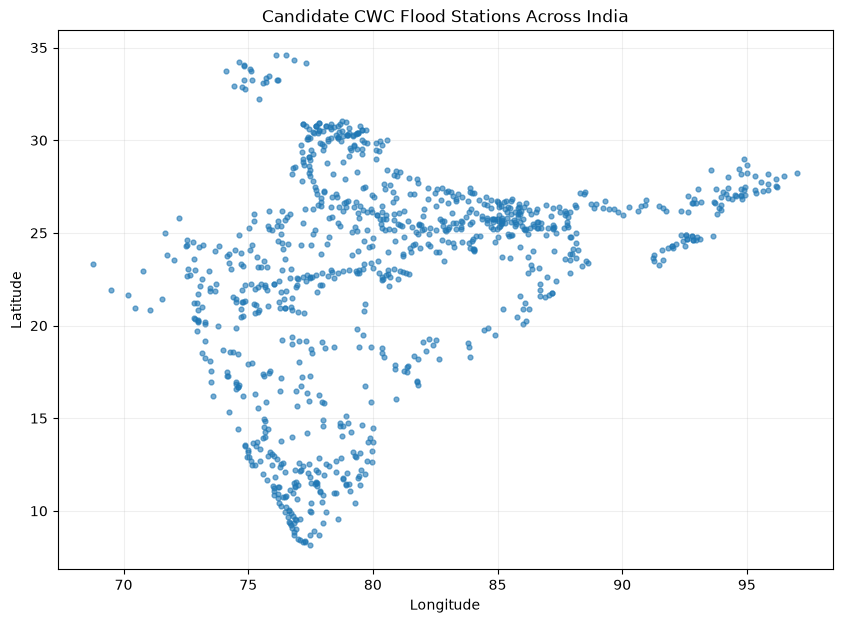

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    candidate_analysis["lon"],
    candidate_analysis["lat"],
    s=12,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Candidate CWC Flood Stations Across India")
plt.grid(alpha=0.2)

plt.show()

In [33]:
rainfall_stats = con.execute(f"""
    SELECT
        COUNT(*) AS total_rainfall_rows,

        COUNT(*) FILTER (
            WHERE sum IS NULL
        ) AS null_sum_rows,

        COUNT(*) FILTER (
            WHERE sum < 0
        ) AS negative_sum_rows,

        COUNT(*) FILTER (
            WHERE sum >= 100
        ) AS ge_100,

        COUNT(*) FILTER (
            WHERE sum >= 500
        ) AS ge_500,

        COUNT(*) FILTER (
            WHERE sum >= 1000
        ) AS ge_1000,

        MAX(sum) AS maximum,

        quantile_cont(sum, 0.99) AS p99,

        quantile_cont(sum, 0.999) AS p999,

        quantile_cont(sum, 0.9999) AS p9999

    FROM read_parquet('{daily_path}')

    WHERE variable = 'rainfall'
      AND sum IS NOT NULL
""").fetchdf()

display(rainfall_stats)

,total_rainfall_rows,null_sum_rows,negative_sum_rows,ge_100,ge_500,ge_1000,maximum,p99,p999,p9999
0,8871559,0,21147,188842,125743,122204,NaN,NaN,NaN,NaN


In [34]:
rainfall_extremes = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        datatype_code,
        unit,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')

    WHERE variable = 'rainfall'
      AND sum IS NOT NULL

    ORDER BY sum DESC

    LIMIT 50
""").fetchdf()

display(rainfall_extremes)

,station_code,date_ist,datatype_code,unit,min,mean,max,sum,n_obs
0,003-MGD2LKN,2019-09-09,MPM,mm,NaN,NaN,NaN,NaN,18
1,003-MGD2LKN,2019-10-17,MPM,mm,NaN,NaN,NaN,NaN,22
2,003-MGD2LKN,2019-09-11,MPM,mm,NaN,NaN,NaN,NaN,20
3,003-MGD2LKN,2019-09-12,MPM,mm,NaN,NaN,NaN,NaN,22
4,003-MGD2LKN,2019-09-13,MPM,mm,NaN,NaN,NaN,NaN,21
5,003-MGD2LKN,2019-09-14,MPM,mm,NaN,NaN,NaN,NaN,16
6,003-MGD2LKN,2019-09-15,MPM,mm,NaN,NaN,NaN,NaN,17
7,003-MGD2LKN,2019-09-16,MPM,mm,NaN,NaN,NaN,NaN,18
8,003-MGD2LKN,2019-09-17,MPM,mm,NaN,NaN,NaN,NaN,22
9,003-MGD2LKN,2019-09-18,MPM,mm,NaN,NaN,NaN,NaN,16


In [35]:
# Check missing overlap values
print("Missing overlap values:",
      candidate_analysis["water_rain_days"].isna().sum())

print("Zero overlap values:",
      (candidate_analysis["water_rain_days"] == 0).sum())

print("\nExact station counts by minimum history:")

for years in [1, 2, 3, 5, 10, 20]:
    minimum_days = int(years * 365.25)

    count = (
        candidate_analysis["water_rain_days"]
        .fillna(0)
        .ge(minimum_days)
        .sum()
    )

    print(f"{years:2d} years ({minimum_days:5d} days): {count:4d} stations")

Missing overlap values: 0
Zero overlap values: 5

Exact station counts by minimum history:
 1 years (  365 days):  858 stations
 2 years (  730 days):  845 stations
 3 years ( 1095 days):  819 stations
 5 years ( 1826 days):  760 stations
10 years ( 3652 days):  438 stations
20 years ( 7305 days):  213 stations


In [36]:
rainfall_extremes = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        datatype_code,
        unit,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')
    WHERE variable = 'rainfall'
      AND sum IS NOT NULL
      AND NOT isnan(sum)
      AND isfinite(sum)
    ORDER BY sum DESC NULLS LAST
    LIMIT 100
""").fetchdf()

display(rainfall_extremes)

,station_code,date_ist,datatype_code,unit,min,mean,max,sum,n_obs
0,008-ERDBWN,2023-01-02,MPM,mm,627.0,627.0,627.0,15048.0,24
1,008-ERDBWN,2022-12-29,MPM,mm,627.0,627.0,627.0,15048.0,24
2,008-ERDBWN,2022-11-09,MPM,mm,627.0,627.0,627.0,15048.0,24
3,008-ERDBWN,2023-01-03,MPM,mm,627.0,627.0,627.0,15048.0,24
4,008-ERDBWN,2022-12-16,MPM,mm,627.0,627.0,627.0,15048.0,24
...,...,...,...,...,...,...,...,...,...
95,008-UGDHYD,2022-07-31,MPM,mm,511.5,511.5,511.5,12276.0,24
96,008-UGDHYD,2022-08-18,MPM,mm,511.5,511.5,511.5,12276.0,24
97,008-UGDHYD,2022-08-30,MPM,mm,511.5,511.5,511.5,12276.0,24
98,008-UGDHYD,2022-09-02,MPM,mm,511.5,511.5,511.5,12276.0,24


In [37]:
rainfall_over_1000 = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        datatype_code,
        unit,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')
    WHERE variable = 'rainfall'
      AND sum IS NOT NULL
      AND NOT isnan(sum)
      AND isfinite(sum)
      AND sum >= 1000
    ORDER BY sum DESC
    LIMIT 100
""").fetchdf()

display(rainfall_over_1000)

,station_code,date_ist,datatype_code,unit,min,mean,max,sum,n_obs
0,008-ERDBWN,2022-10-30,MPM,mm,627.0,627.0,627.0,15048.0,24
1,008-ERDBWN,2023-01-01,MPM,mm,627.0,627.0,627.0,15048.0,24
2,008-ERDBWN,2022-10-12,MPM,mm,627.0,627.0,627.0,15048.0,24
3,008-ERDBWN,2022-12-11,MPM,mm,627.0,627.0,627.0,15048.0,24
4,008-ERDBWN,2023-01-03,MPM,mm,627.0,627.0,627.0,15048.0,24
...,...,...,...,...,...,...,...,...,...
95,008-UGDHYD,2022-09-01,MPM,mm,511.5,511.5,511.5,12276.0,24
96,008-UGDHYD,2022-09-22,MPM,mm,511.5,511.5,511.5,12276.0,24
97,008-UGDHYD,2022-08-26,MPM,mm,511.5,511.5,511.5,12276.0,24
98,008-UGDHYD,2022-08-29,MPM,mm,511.5,511.5,511.5,12276.0,24


In [38]:
rainfall_over_500 = con.execute(f"""
    SELECT
        datatype_code,
        COUNT(*) AS rows,
        MIN(sum) AS minimum,
        quantile_cont(sum, 0.50) AS median,
        quantile_cont(sum, 0.90) AS p90,
        quantile_cont(sum, 0.99) AS p99,
        MAX(sum) AS maximum
    FROM read_parquet('{daily_path}')
    WHERE variable = 'rainfall'
      AND sum IS NOT NULL
      AND NOT isnan(sum)
      AND isfinite(sum)
      AND sum >= 500
    GROUP BY datatype_code
    ORDER BY rows DESC
""").fetchdf()

display(rainfall_over_500)

,datatype_code,rows,minimum,median,p90,p99,maximum
0,MPM,7796,500.0,1287.0,5760.00,12799.200,15048.0
1,MPS,285,500.0,614.2,851.84,1710.248,7581.4
2,MPA,8,500.0,590.5,703.18,862.318,880.0


In [39]:
rainfall_missing = con.execute(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(*) FILTER (WHERE sum IS NULL) AS null_values,
        COUNT(*) FILTER (WHERE isnan(sum)) AS nan_values,
        COUNT(*) FILTER (WHERE isfinite(sum) = false) AS nonfinite_values
    FROM read_parquet('{daily_path}')
    WHERE variable = 'rainfall'
""").fetchdf()

display(rainfall_missing)

,total,null_values,nan_values,nonfinite_values
0,8871559,0,117654,117654


In [41]:
mpm_patterns = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(*) FILTER (
            WHERE n_obs = 24
        ) AS nobs_24,

        COUNT(*) FILTER (
            WHERE n_obs = 24
              AND min = mean
              AND mean = max
        ) AS constant_24,

        COUNT(*) FILTER (
            WHERE n_obs = 24
              AND min = mean
              AND mean = max
              AND sum = mean * n_obs
        ) AS exact_repeat_pattern

    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPM'
""").fetchdf()

display(mpm_patterns)

,total_rows,nobs_24,constant_24,exact_repeat_pattern
0,817793,315896,248089,248089


In [42]:
mpm_values = con.execute(f"""
    SELECT
        mean,
        n_obs,
        COUNT(*) AS rows,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date
    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPM'
      AND mean IS NOT NULL
      AND NOT isnan(mean)
      AND isfinite(mean)

    GROUP BY mean, n_obs
    ORDER BY rows DESC
    LIMIT 30
""").fetchdf()

display(mpm_values)

,mean,n_obs,rows,first_date,last_date
0,0.000000,24,194587,2014-06-01,2026-09-09
1,0.000000,23,41576,2014-06-04,2026-09-10
2,0.000000,22,23290,2014-06-06,2026-09-10
3,0.000000,19,21753,2014-08-02,2026-09-09
4,0.000000,21,17687,2014-07-29,2026-09-08
5,0.000000,1,17251,1900-06-15,2026-09-10
6,0.000000,20,16141,2014-08-18,2026-09-09
7,0.000000,18,13719,2014-09-05,2026-09-10
8,0.000000,17,12994,2014-09-08,2026-09-10
9,0.000000,12,11301,2014-06-02,2026-09-09


In [43]:
mps_extremes = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPS'
      AND sum IS NOT NULL
      AND NOT isnan(sum)
      AND isfinite(sum)

    ORDER BY sum DESC

    LIMIT 100
""").fetchdf()

display(mps_extremes)

,station_code,date_ist,min,mean,max,sum,n_obs
0,010-MDSIL,2005-05-14,6.4,2527.133333,7506.0,7581.4,3
1,040-MAHGAND,2017-07-24,0.0,81.622222,740.4,2203.8,27
2,010-CDJAPR,1994-08-25,2082.2,2082.200000,2082.2,2082.2,1
3,040-MAHGAND,2017-07-25,0.0,60.718519,733.6,1639.4,27
4,033-MAHGAND,2017-07-24,0.0,60.629630,529.0,1637.0,27
...,...,...,...,...,...,...,...
95,025-LGDHYD,1996-06-17,675.0,675.000000,675.0,675.0,1
96,013-UYDDEL,2007-06-16,61.0,337.500000,614.0,675.0,2
97,01-10-01-001,2024-10-04,0.0,84.250000,239.2,674.0,8
98,006RUPALI,2009-08-17,3.0,26.960000,337.0,674.0,25


In [44]:
negative_rainfall = con.execute(f"""
    SELECT
        datatype_code,
        sum,
        COUNT(*) AS rows
    FROM read_parquet('{daily_path}')

    WHERE variable = 'rainfall'
      AND sum IS NOT NULL
      AND NOT isnan(sum)
      AND sum < 0

    GROUP BY datatype_code, sum
    ORDER BY rows DESC, sum
    LIMIT 50
""").fetchdf()

display(negative_rainfall)

,datatype_code,sum,rows
0,MPS,-999.00,6904
1,MPS,-23976.00,6428
2,MPS,-22977.00,4255
3,MPS,-1998.00,1073
4,MPA,-23976.00,195
5,MPS,-998.80,87
6,MPS,-998.60,47
7,MPS,-998.00,40
8,MPS,-998.20,38
9,MPS,-997.60,36


In [45]:
rainfall_code_coverage = con.execute(f"""
    SELECT
        datatype_code,
        COUNT(*) AS rows,
        COUNT(DISTINCT station_code) AS stations,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date,
        SUM(n_obs) AS raw_observations
    FROM read_parquet('{daily_path}')

    WHERE variable = 'rainfall'

    GROUP BY datatype_code
    ORDER BY rows DESC
""").fetchdf()

display(rainfall_code_coverage)

,datatype_code,rows,stations,first_date,last_date,raw_observations
0,MPS,7683511,1549,1960-05-01,2026-09-11,19546585.0
1,MPM,817793,641,1900-06-15,2026-09-10,15389091.0
2,MPA,367135,123,1964-06-01,2026-02-28,1056955.0
3,MPN,3120,4,1995-03-01,2015-12-30,3850.0


In [46]:
mpm_vs_mps = con.execute(f"""
    WITH rainfall AS (
        SELECT
            station_code,
            date_ist,
            datatype_code,
            min,
            mean,
            max,
            sum,
            n_obs
        FROM read_parquet('{daily_path}')
        WHERE variable = 'rainfall'
          AND datatype_code IN ('MPM', 'MPS')
          AND sum IS NOT NULL
          AND NOT isnan(sum)
          AND isfinite(sum)
    )

    SELECT
        mpm.station_code,
        mpm.date_ist,

        mpm.min  AS mpm_min,
        mpm.mean AS mpm_mean,
        mpm.max  AS mpm_max,
        mpm.sum  AS mpm_sum,
        mpm.n_obs AS mpm_n_obs,

        mps.min  AS mps_min,
        mps.mean AS mps_mean,
        mps.max  AS mps_max,
        mps.sum  AS mps_sum,
        mps.n_obs AS mps_n_obs

    FROM rainfall mpm
    JOIN rainfall mps
      ON mpm.station_code = mps.station_code
     AND mpm.date_ist = mps.date_ist

    WHERE mpm.datatype_code = 'MPM'
      AND mps.datatype_code = 'MPS'
      AND mpm.n_obs = 24
      AND mpm.min = mpm.mean
      AND mpm.mean = mpm.max
      AND mpm.mean > 0

    ORDER BY mpm.sum DESC

    LIMIT 100
""").fetchdf()

display(mpm_vs_mps)

,station_code,date_ist,mpm_min,mpm_mean,mpm_max,mpm_sum,mpm_n_obs,mps_min,mps_mean,mps_max,mps_sum,mps_n_obs
0,008-ERDBWN,2022-12-29,627.0,627.0,627.0,15048.0,24,0.0,0.0,0.0,0.0,1
1,008-ERDBWN,2022-12-18,627.0,627.0,627.0,15048.0,24,0.0,0.0,0.0,0.0,1
2,008-ERDBWN,2022-11-01,627.0,627.0,627.0,15048.0,24,0.0,0.0,0.0,0.0,1
3,008-ERDBWN,2022-12-16,627.0,627.0,627.0,15048.0,24,0.0,0.0,0.0,0.0,1
4,008-ERDBWN,2022-12-15,627.0,627.0,627.0,15048.0,24,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,064--ERDBWN,2020-08-22,489.8,489.8,489.8,11755.2,24,3.6,3.6,3.6,3.6,1
96,008-UBDDIB,2021-06-16,486.0,486.0,486.0,11664.0,24,0.0,0.0,0.0,0.0,1
97,008-UBDDIB,2021-06-17,486.0,486.0,486.0,11664.0,24,0.0,0.0,0.0,0.0,1
98,008-UBDDIB,2021-06-11,460.0,460.0,460.0,11040.0,24,2.4,2.4,2.4,2.4,1


In [49]:
mpm_station = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPM'
      AND station_code = '008-ERDBWN'

    ORDER BY date_ist

    LIMIT 200
""").fetchdf()

display(mpm_station)

,station_code,date_ist,min,mean,max,sum,n_obs
0,008-ERDBWN,2019-02-01,0.0,0.0,0.0,0.0,19
1,008-ERDBWN,2019-02-02,0.0,0.0,0.0,0.0,24
2,008-ERDBWN,2019-02-03,0.0,0.0,0.0,0.0,24
3,008-ERDBWN,2019-02-04,0.0,0.0,0.0,0.0,24
4,008-ERDBWN,2019-02-05,0.0,0.0,0.0,0.0,24
...,...,...,...,...,...,...,...
195,008-ERDBWN,2019-10-01,NaN,NaN,NaN,NaN,24
196,008-ERDBWN,2019-10-02,NaN,NaN,NaN,NaN,24
197,008-ERDBWN,2019-10-03,NaN,NaN,NaN,NaN,24
198,008-ERDBWN,2019-10-04,NaN,NaN,NaN,NaN,23


In [50]:
mpm_station_2 = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPM'
      AND station_code = '008-UGDHYD'

    ORDER BY date_ist

    LIMIT 200
""").fetchdf()

display(mpm_station_2)

,station_code,date_ist,min,mean,max,sum,n_obs
0,008-UGDHYD,1970-11-10,511.5,511.500000,511.5,511.5,1
1,008-UGDHYD,1976-01-11,511.5,511.500000,511.5,511.5,1
2,008-UGDHYD,2019-02-01,0.0,0.000000,0.0,0.0,19
3,008-UGDHYD,2019-02-02,0.0,0.000000,0.0,0.0,24
4,008-UGDHYD,2019-02-03,0.0,0.000000,0.0,0.0,24
...,...,...,...,...,...,...,...
195,008-UGDHYD,2019-09-28,0.0,0.000000,0.0,0.0,23
196,008-UGDHYD,2019-09-29,0.0,0.021739,0.5,0.5,23
197,008-UGDHYD,2019-09-30,0.0,0.000000,0.0,0.0,23
198,008-UGDHYD,2019-10-01,0.0,0.000000,0.0,0.0,24


In [51]:
mpm_vs_mps = con.execute(f"""
    WITH rainfall AS (
        SELECT
            station_code,
            date_ist,
            datatype_code,
            min,
            mean,
            max,
            sum,
            n_obs
        FROM read_parquet('{daily_path}')
        WHERE variable = 'rainfall'
          AND datatype_code IN ('MPM', 'MPS')
          AND sum IS NOT NULL
          AND NOT isnan(sum)
          AND isfinite(sum)
    )

    SELECT
        mpm.station_code,
        mpm.date_ist,
        mpm.mean AS mpm_mean,
        mpm.sum AS mpm_sum,
        mpm.n_obs AS mpm_n_obs,
        mps.mean AS mps_mean,
        mps.sum AS mps_sum,
        mps.n_obs AS mps_n_obs

    FROM rainfall mpm
    JOIN rainfall mps
      ON mpm.station_code = mps.station_code
     AND mpm.date_ist = mps.date_ist

    WHERE mpm.datatype_code = 'MPM'
      AND mps.datatype_code = 'MPS'
      AND mpm.n_obs = 24
      AND mpm.min = mpm.mean
      AND mpm.mean = mpm.max
      AND mpm.mean > 0

    ORDER BY mpm.sum DESC

    LIMIT 100
""").fetchdf()

display(mpm_vs_mps)

,station_code,date_ist,mpm_mean,mpm_sum,mpm_n_obs,mps_mean,mps_sum,mps_n_obs
0,008-ERDBWN,2023-01-07,627.0,15048.0,24,0.0,0.0,1
1,008-ERDBWN,2022-12-11,627.0,15048.0,24,0.0,0.0,1
2,008-ERDBWN,2022-11-05,627.0,15048.0,24,0.0,0.0,1
3,008-ERDBWN,2022-12-15,627.0,15048.0,24,0.0,0.0,1
4,008-ERDBWN,2022-12-26,627.0,15048.0,24,0.0,0.0,1
...,...,...,...,...,...,...,...,...
95,064--ERDBWN,2020-08-22,489.8,11755.2,24,3.6,3.6,1
96,008-UBDDIB,2021-06-17,486.0,11664.0,24,0.0,0.0,1
97,008-UBDDIB,2021-06-16,486.0,11664.0,24,0.0,0.0,1
98,008-UBDDIB,2021-06-11,460.0,11040.0,24,2.4,2.4,1


In [52]:
mpm_station = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPM'
      AND station_code = '008-ERDBWN'

    ORDER BY date_ist
    LIMIT 200
""").fetchdf()

display(mpm_station)

,station_code,date_ist,min,mean,max,sum,n_obs
0,008-ERDBWN,2019-02-01,0.0,0.0,0.0,0.0,19
1,008-ERDBWN,2019-02-02,0.0,0.0,0.0,0.0,24
2,008-ERDBWN,2019-02-03,0.0,0.0,0.0,0.0,24
3,008-ERDBWN,2019-02-04,0.0,0.0,0.0,0.0,24
4,008-ERDBWN,2019-02-05,0.0,0.0,0.0,0.0,24
...,...,...,...,...,...,...,...
195,008-ERDBWN,2019-10-01,NaN,NaN,NaN,NaN,24
196,008-ERDBWN,2019-10-02,NaN,NaN,NaN,NaN,24
197,008-ERDBWN,2019-10-03,NaN,NaN,NaN,NaN,24
198,008-ERDBWN,2019-10-04,NaN,NaN,NaN,NaN,23


In [53]:
mps_extreme_counts = con.execute(f"""
    SELECT
        COUNT(*) AS total_valid_mps,

        COUNT(*) FILTER (WHERE sum >= 100) AS ge_100,
        COUNT(*) FILTER (WHERE sum >= 200) AS ge_200,
        COUNT(*) FILTER (WHERE sum >= 300) AS ge_300,
        COUNT(*) FILTER (WHERE sum >= 500) AS ge_500,
        COUNT(*) FILTER (WHERE sum >= 1000) AS ge_1000,
        COUNT(*) FILTER (WHERE sum >= 2000) AS ge_2000,
        COUNT(*) FILTER (WHERE sum >= 5000) AS ge_5000,

        MAX(sum) AS maximum

    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPS'
      AND sum IS NOT NULL
      AND NOT isnan(sum)
      AND isfinite(sum)
      AND sum >= 0
""").fetchdf()

display(mps_extreme_counts)

,total_valid_mps,ge_100,ge_200,ge_300,ge_500,ge_1000,ge_2000,ge_5000,maximum
0,7662602,44406,6742,1768,285,17,3,1,7581.4


In [54]:
mps_top = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        sum,
        n_obs
    FROM read_parquet('{daily_path}')

    WHERE datatype_code = 'MPS'
      AND sum IS NOT NULL
      AND NOT isnan(sum)
      AND isfinite(sum)
      AND sum >= 1000

    ORDER BY sum DESC

    LIMIT 50
""").fetchdf()

display(mps_top)

,station_code,date_ist,min,mean,max,sum,n_obs
0,010-MDSIL,2005-05-14,6.4,2527.133333,7506.00000,7581.40000,3
1,040-MAHGAND,2017-07-24,0.0,81.622222,740.40000,2203.80000,27
2,010-CDJAPR,1994-08-25,2082.2,2082.200000,2082.20000,2082.20000,1
3,040-MAHGAND,2017-07-25,0.0,60.718519,733.60000,1639.40000,27
4,033-MAHGAND,2017-07-24,0.0,60.629630,529.00000,1637.00000,27
5,030-MAHGAND,2017-07-24,6.4,58.592593,445.40000,1582.00000,27
6,019-UYDDEL,1978-07-22,1300.0,1300.000000,1300.00000,1300.00000,1
7,003-LYDAGRA,2007-07-09,1270.0,1270.000000,1270.00000,1270.00000,1
8,002-MIDSHL,2005-08-28,0.0,43.187407,444.30000,1166.06000,27
9,014-UGDHYD,2005-11-01,309.8,573.400000,837.00000,1146.80000,2


In [55]:
water_level_quality = con.execute(f"""
    SELECT
        datatype_code,

        COUNT(*) AS total_rows,

        COUNT(*) FILTER (
            WHERE mean IS NULL
        ) AS null_mean,

        COUNT(*) FILTER (
            WHERE isnan(mean)
        ) AS nan_mean,

        COUNT(*) FILTER (
            WHERE mean <= -9000
        ) AS extreme_negative,

        COUNT(*) FILTER (
            WHERE mean < 0
        ) AS negative,

        MIN(mean) AS minimum,
        MAX(mean) AS maximum

    FROM read_parquet('{daily_path}')

    WHERE variable = 'water_level'

    GROUP BY datatype_code

    ORDER BY total_rows DESC
""").fetchdf()

display(water_level_quality)

,datatype_code,total_rows,null_mean,nan_mean,extreme_negative,negative,minimum,maximum
0,HHS,8558926,0,0,1,20805,-9990.000,663559.513333
1,HZS,3028113,0,0,0,55019,-3042.610,131858.523000
2,HHT,787352,0,27119,0,10672,-985.830,NaN
3,HZF,159395,0,0,0,486,-6233.596,688700.000000
4,HHX,21166,0,0,0,0,1.750,3739.133333
5,HHA,1249,0,0,0,0,11.560,292.813750


In [56]:
water_level_bad = con.execute(f"""
    SELECT
        datatype_code,
        mean,
        COUNT(*) AS rows
    FROM read_parquet('{daily_path}')

    WHERE variable = 'water_level'
      AND mean IS NOT NULL
      AND (
          mean <= -9000
          OR mean < 0
      )

    GROUP BY datatype_code, mean

    ORDER BY rows DESC

    LIMIT 50
""").fetchdf()

display(water_level_bad)

,datatype_code,mean,rows
0,HHS,-999.000000,8539
1,HHS,-836.875000,1755
2,HZS,-1.000000,1299
3,HHS,-2.000000,931
4,HZS,-0.000006,616
5,HZS,-0.000012,489
6,HZS,-195.000000,435
7,HZS,-0.300000,390
8,HHS,-1.777778,268
9,HZS,-0.200000,263


In [57]:
water_level_top = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        datatype_code,
        min,
        mean,
        max,
        n_obs
    FROM read_parquet('{daily_path}')

    WHERE variable = 'water_level'
      AND mean IS NOT NULL
      AND NOT isnan(mean)
      AND isfinite(mean)
      AND mean > 0

    ORDER BY mean DESC

    LIMIT 100
""").fetchdf()

display(water_level_top)

,station_code,date_ist,datatype_code,min,mean,max,n_obs
0,738BB092,2022-09-13,HHT,976379.000,1.003468e+06,1018363.00,22
1,738BB092,2022-09-26,HHT,985584.000,9.855840e+05,985584.00,2
2,738CFF7E,2022-10-02,HHT,973843.000,9.738430e+05,973843.00,1
3,738B967E,2022-07-31,HHT,973842.000,9.738420e+05,973842.00,17
4,738B967E,2022-07-17,HHT,972818.000,9.737140e+05,973842.00,8
...,...,...,...,...,...,...,...
95,738CFF7E,2022-09-17,HHT,374798.000,5.698081e+05,665622.00,23
96,738CE2DA,2025-09-03,HHT,970.810,5.692542e+05,875411.94,3
97,738CFF7E,2022-09-19,HHT,0.000,5.662049e+05,784406.00,12
98,018-CHEJMU,2022-05-01,HHT,5966.254,5.649848e+05,1022798.25,24


In [58]:
water_level_station_stats = con.execute(f"""
    SELECT
        station_code,

        COUNT(*) AS rows,

        quantile_cont(mean, 0.01) AS p01,
        quantile_cont(mean, 0.50) AS median,
        quantile_cont(mean, 0.99) AS p99,
        quantile_cont(mean, 0.999) AS p999,

        MIN(mean) AS minimum,
        MAX(mean) AS maximum

    FROM read_parquet('{daily_path}')

    WHERE variable = 'water_level'
      AND mean IS NOT NULL
      AND NOT isnan(mean)
      AND isfinite(mean)
      AND mean > -9000

    GROUP BY station_code

    HAVING COUNT(*) >= 100

    ORDER BY maximum DESC

    LIMIT 100
""").fetchdf()

display(water_level_station_stats)

,station_code,rows,p01,median,p99,p999,minimum,maximum
0,738BB092,1493,0.000000,499.500333,274961.783333,937093.267200,0.00,1.003468e+06
1,738CFF7E,1428,0.000000,507.381646,774176.000000,886252.660333,0.00,9.738430e+05
2,738B967E,1707,0.000000,891.049000,973375.088379,973659.779200,0.00,9.738420e+05
3,738CEC08,1330,0.000000,969.231000,410202.610048,875657.170667,0.00,9.420250e+05
4,026-LBDJPG,11228,111.438600,156.970000,854.268636,1056.546261,0.00,8.143084e+05
...,...,...,...,...,...,...,...,...
95,004-DDASL,10849,189.750000,190.880000,193.786100,196.519557,0.00,1.909600e+04
96,034-UYDDEL,2627,624.900000,625.635833,627.021483,628.301297,623.14,1.867931e+04
97,022-LKDHYD,27381,-0.694333,44.033333,46.493333,86.660643,-12.58,1.852339e+04
98,007-CDJAIPUR,3367,379.365892,396.230000,404.690000,2050.753987,0.00,1.839473e+04


In [59]:
hzf_top = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        n_obs
    FROM read_parquet('{daily_path}')
    WHERE datatype_code = 'HZF'
      AND mean IS NOT NULL
      AND isfinite(mean)
    ORDER BY mean DESC
    LIMIT 30
""").fetchdf()

display(hzf_top)

,station_code,date_ist,min,mean,max,n_obs
0,026-UGDHYD,2021-02-21,688700.000,688700.000000,6.887000e+05,1
1,026-UGDHYD,2023-04-16,680225.000,680225.000000,6.802250e+05,1
2,023-UGDHYD,2019-10-31,1091.001,455674.250958,1.091109e+07,24
3,002NEID3,2026-06-07,14.370,291449.541375,6.994456e+06,24
4,0031-CDBNG,2018-03-21,281478.000,281478.000000,2.814780e+05,1
5,053-TDSURAT,2025-06-26,1.050,93099.941375,1.117192e+06,24
6,009-UGDHYD,2022-02-24,1517.920,51609.280000,1.517920e+05,3
7,019-UGDHYD,2025-11-27,1405.000,47770.000000,1.405000e+05,3
8,49-LGDHYD,2018-11-01,9011.812,36024.061333,9.004856e+04,3
9,026-UGDHYD,2025-09-21,699.199,29825.658417,6.997250e+05,24


In [60]:
hzf_negative = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        n_obs
    FROM read_parquet('{daily_path}')
    WHERE datatype_code = 'HZF'
      AND mean IS NOT NULL
      AND mean < 0
    ORDER BY mean
    LIMIT 30
""").fetchdf()

display(hzf_negative)

,station_code,date_ist,min,mean,max,n_obs
0,0013NEID3,2025-06-16,-6233.596,-6233.59600,-6233.596,5
1,0013NEID3,2025-05-27,-6213.911,-6213.91100,-6213.911,1
2,0013NEID3,2025-05-29,-5798.557,-5798.55700,-5798.557,1
3,001NEID3,2024-03-23,-7309.711,-1820.53775,9.252,4
4,001NEID3,2023-11-24,-7309.711,-1820.16900,9.744,4
5,001NEID3,2023-11-08,-7309.711,-1819.97200,10.007,4
6,002NEID3,2024-03-23,-6988.189,-1737.45100,12.861,4
7,002NEID3,2023-11-24,-6988.189,-1737.08150,13.353,4
8,0013NEID3,2024-02-26,-6233.596,-1544.53750,18.504,4
9,0013NEID3,2024-04-04,-6230.315,-1542.92975,19.554,4


In [61]:
hhs_negative_stations = con.execute(f"""
    SELECT
        station_code,
        COUNT(*) AS negative_rows,
        MIN(mean) AS minimum,
        MAX(mean) AS maximum,
        quantile_cont(mean, 0.50) AS median
    FROM read_parquet('{daily_path}')
    WHERE datatype_code = 'HHS'
      AND mean IS NOT NULL
      AND mean < -10
      AND mean > -9000
    GROUP BY station_code
    ORDER BY negative_rows DESC
    LIMIT 50
""").fetchdf()

display(hhs_negative_stations)

,station_code,negative_rows,minimum,maximum,median
0,017-CDJAPR,11684,-999.000000,-566.666667,-999.000000
1,024-MGD5PAT,754,-999.000000,-446.073750,-848.232500
2,041-CDJAPR,138,-999.000000,-426.920833,-999.000000
3,014-UYDDEL,31,-948.685000,-848.131667,-848.152500
4,001-MGD3VNS,29,-999.000000,-295.666667,-999.000000
5,047-MGD1LKN,29,-999.000000,-681.029667,-999.000000
6,NBO-1-044-1245,28,-999.000000,-862.322500,-999.000000
7,049-MGD1LKN,25,-999.000000,-999.000000,-999.000000
8,009-NDBHP,22,-999.000000,-878.825000,-999.000000
9,0010NEID3,19,-999.000000,-999.000000,-999.000000


In [62]:
hhs_minus_836 = con.execute(f"""
    SELECT
        station_code,
        date_ist,
        min,
        mean,
        max,
        n_obs
    FROM read_parquet('{daily_path}')
    WHERE datatype_code = 'HHS'
      AND mean BETWEEN -850 AND -820
    ORDER BY station_code, date_ist
    LIMIT 100
""").fetchdf()

display(hhs_minus_836)

,station_code,date_ist,min,mean,max,n_obs
0,014-UYDDEL,2004-01-02,-999.0,-848.150417,207.800,24
1,014-UYDDEL,2004-01-03,-999.0,-848.152500,207.780,24
2,014-UYDDEL,2004-01-04,-999.0,-848.153333,207.780,24
3,014-UYDDEL,2004-01-05,-999.0,-848.150000,207.800,24
4,014-UYDDEL,2004-01-06,-999.0,-848.149167,207.810,24
...,...,...,...,...,...,...
95,017-CDJAPR,1995-03-07,-999.0,-836.514042,300.888,24
96,017-CDJAPR,1995-03-08,-999.0,-836.514375,300.885,24
97,017-CDJAPR,1995-03-09,-999.0,-836.514542,300.884,24
98,017-CDJAPR,1995-03-10,-999.0,-836.514500,300.885,24


In [63]:
weird_water_stations = con.execute(f"""
    SELECT
        station_code,
        COUNT(*) AS rows,
        quantile_cont(mean, 0.50) AS median,
        quantile_cont(mean, 0.99) AS p99,
        MAX(mean) AS maximum
    FROM read_parquet('{daily_path}')
    WHERE variable = 'water_level'
      AND mean IS NOT NULL
      AND isfinite(mean)
      AND mean > -9000
    GROUP BY station_code
    HAVING MAX(mean) > 10000
    ORDER BY maximum DESC
""").fetchdf()

print("Stations with water level > 10,000:")
print(len(weird_water_stations))

display(weird_water_stations.head(100))

Stations with water level > 10,000:
123


,station_code,rows,median,p99,maximum
0,738BB092,1493,499.500333,274961.783333,1.003468e+06
1,738CFF7E,1428,507.381646,774176.000000,9.738430e+05
2,738B967E,1707,891.049000,973375.088379,9.738420e+05
3,738CEC08,1330,969.231000,410202.610048,9.420250e+05
4,026-LBDJPG,11228,156.970000,854.268636,8.143084e+05
...,...,...,...,...,...
95,004-DDASL,10849,190.880000,193.786100,1.909600e+04
96,034-UYDDEL,2627,625.635833,627.021483,1.867931e+04
97,022-LKDHYD,27381,44.033333,46.493333,1.852339e+04
98,007-CDJAIPUR,3367,396.230000,404.690000,1.839473e+04


In [67]:
water_code_station_summary = con.execute(f"""
    SELECT
        station_code,
        datatype_code,
        COUNT(*) AS rows,
        MIN(date_ist) AS first_date,
        MAX(date_ist) AS last_date,
        COUNT(DISTINCT date_ist) AS days,
        quantile_cont(mean, 0.50) AS median,
        quantile_cont(mean, 0.01) AS p01,
        quantile_cont(mean, 0.99) AS p99,
        MAX(mean) AS maximum
    FROM read_parquet('{daily_path}')
    WHERE variable = 'water_level'
      AND mean IS NOT NULL
      AND isfinite(mean)
      AND mean > -9000
    GROUP BY station_code, datatype_code
    ORDER BY station_code, days DESC
""").fetchdf()

print("Station-code combinations:", len(water_code_station_summary))
display(water_code_station_summary.head(100))

Station-code combinations: 3139


,station_code,datatype_code,rows,first_date,last_date,days,median,p01,p99,maximum
0,001-CDBNG,HHS,12959,1988-12-01,2026-09-11,12959,558.856188,6.542983,565.612608,3857.926667
1,001-CDBNG,HZS,7592,1980-01-01,2026-09-11,7592,3.250000,0.595000,558.881200,563.373333
2,001-CDBNG,HHT,1047,1970-01-22,2026-05-01,1047,562.210000,0.011000,709.877528,770.111000
3,001-CDJPR,HHS,12483,1991-01-01,2026-09-11,12483,466.368333,465.000000,471.399147,752.160000
4,001-CDJPR,HZS,5564,1991-06-16,2026-09-11,5564,2.635833,0.000000,470.089133,470.770000
...,...,...,...,...,...,...,...,...,...,...
95,002-JHELUM,HZS,8039,1997-01-01,2026-09-11,8039,3.000000,1.290000,9.973575,15.580000
96,002-JHELUM,HHT,765,2022-01-01,2026-09-02,765,1586.118136,1562.215625,1636.753072,1728.668000
97,002-LBDJPG,HHS,7161,1991-08-23,2026-09-11,7161,43.350000,42.135333,45.445333,61.363913
98,002-LBDJPG,HHT,1888,1969-12-20,2026-09-01,1888,44.851382,3.603354,916.090248,1017.625000


In [68]:
water_code_counts = con.execute(f"""
    SELECT
        datatype_code,
        COUNT(DISTINCT station_code) AS stations,
        COUNT(*) AS rows,
        COUNT(DISTINCT date_ist) AS dates
    FROM read_parquet('{daily_path}')
    WHERE variable = 'water_level'
    GROUP BY datatype_code
    ORDER BY stations DESC
""").fetchdf()

display(water_code_counts)

,datatype_code,stations,rows,dates
0,HHS,1609,8558926,25825
1,HZS,786,3028113,23450
2,HHT,626,787352,4982
3,HZF,99,159395,6602
4,HHX,17,21166,4366
5,HHA,2,1249,1249


In [69]:
multi_water_code = con.execute(f"""
    SELECT
        station_code,
        COUNT(DISTINCT datatype_code) AS water_codes,
        STRING_AGG(DISTINCT datatype_code, ', ') AS codes
    FROM read_parquet('{daily_path}')
    WHERE variable = 'water_level'
    GROUP BY station_code
    HAVING COUNT(DISTINCT datatype_code) > 1
    ORDER BY water_codes DESC
""").fetchdf()

print("Stations with multiple water-level codes:", len(multi_water_code))
display(multi_water_code.head(100))

Stations with multiple water-level codes: 1128


,station_code,water_codes,codes
0,015-LGDHYD,4,"HHT, HZS, HZF, HHS"
1,011-UGDHYD,4,"HHS, HZF, HHT, HZS"
2,01-11-06-003,4,"HHX, HHT, HZS, HHS"
3,027-UGDHYD,4,"HHS, HZF, HHT, HZS"
4,021-LGDHYD,4,"HHT, HZS, HZF, HHS"
...,...,...,...
95,008-LYDAGRA,3,"HHT, HZS, HHS"
96,017-CDBNG,3,"HHT, HZS, HHS"
97,056-ERDBWN,3,"HHT, HZF, HHS"
98,032-ADSL,3,"HHT, HZS, HHS"


In [70]:
water_code_vs_thresholds = con.execute(f"""
    SELECT
        d.station_code,
        d.datatype_code,

        s.name,
        s.type,
        s.warning_level,
        s.danger_level,

        COUNT(*) AS rows,
        COUNT(DISTINCT d.date_ist) AS days,

        MIN(d.date_ist) AS first_date,
        MAX(d.date_ist) AS last_date,

        quantile_cont(d.mean, 0.01) AS p01,
        quantile_cont(d.mean, 0.50) AS median,
        quantile_cont(d.mean, 0.90) AS p90,
        quantile_cont(d.mean, 0.99) AS p99,
        MAX(d.mean) AS maximum

    FROM read_parquet('{daily_path}') d

    LEFT JOIN stations s
        ON d.station_code = s.station_code

    WHERE d.variable = 'water_level'
      AND d.mean IS NOT NULL
      AND isfinite(d.mean)
      AND d.mean > -9000

    GROUP BY
        d.station_code,
        d.datatype_code,
        s.name,
        s.type,
        s.warning_level,
        s.danger_level

    ORDER BY d.station_code, days DESC
""").fetchdf()

print("Rows:", len(water_code_vs_thresholds))
display(water_code_vs_thresholds.head(100))

Rows: 3139


,station_code,datatype_code,name,type,warning_level,danger_level,rows,days,first_date,last_date,p01,median,p90,p99,maximum
0,001-CDBNG,HHS,Shimoga,Base,566.70,567.25,12959,12959,1988-12-01,2026-09-11,6.542983,558.856188,563.043417,565.612608,3857.926667
1,001-CDBNG,HZS,Shimoga,Base,566.70,567.25,7592,7592,1980-01-01,2026-09-11,0.595000,3.250000,5.877583,558.881200,563.373333
2,001-CDBNG,HHT,Shimoga,Base,566.70,567.25,1047,1047,1970-01-22,2026-05-01,0.011000,562.210000,570.769029,709.877528,770.111000
3,001-CDJPR,HHS,Dhareri,Base,478.50,479.50,12483,12483,1991-01-01,2026-09-11,465.000000,466.368333,470.021333,471.399147,752.160000
4,001-CDJPR,HZS,Dhareri,Base,478.50,479.50,5564,5564,1991-06-16,2026-09-11,0.000000,2.635833,13.838667,470.089133,470.770000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,002-JHELUM,HZS,Sangam,Level,1591.20,1592.42,8039,8039,1997-01-01,2026-09-11,1.290000,3.000000,8.130167,9.973575,15.580000
96,002-JHELUM,HHT,Sangam,Level,1591.20,1592.42,765,765,2022-01-01,2026-09-02,1562.215625,1586.118136,1586.737971,1636.753072,1728.668000
97,002-LBDJPG,HHS,Beki Road bridge,Level,44.10,45.10,7161,7161,1991-08-23,2026-09-11,42.135333,43.350000,44.806667,45.445333,61.363913
98,002-LBDJPG,HHT,Beki Road bridge,Level,44.10,45.10,1888,1888,1969-12-20,2026-09-01,3.603354,44.851382,461.462500,916.090248,1017.625000


In [71]:
hhs_hzs_compare = con.execute(f"""
    WITH stats AS (
        SELECT
            station_code,
            datatype_code,

            COUNT(*) AS days,
            MIN(date_ist) AS first_date,
            MAX(date_ist) AS last_date,

            quantile_cont(mean, 0.01) AS p01,
            quantile_cont(mean, 0.50) AS median,
            quantile_cont(mean, 0.90) AS p90,
            quantile_cont(mean, 0.99) AS p99,
            MAX(mean) AS maximum

        FROM read_parquet('{daily_path}')

        WHERE variable = 'water_level'
          AND datatype_code IN ('HHS', 'HZS')
          AND mean IS NOT NULL
          AND isfinite(mean)
          AND mean > -9000

        GROUP BY station_code, datatype_code
    )

    SELECT
        station_code,

        MAX(CASE WHEN datatype_code = 'HHS' THEN days END) AS hhs_days,
        MAX(CASE WHEN datatype_code = 'HZS' THEN days END) AS hzs_days,

        MAX(CASE WHEN datatype_code = 'HHS' THEN median END) AS hhs_median,
        MAX(CASE WHEN datatype_code = 'HZS' THEN median END) AS hzs_median,

        MAX(CASE WHEN datatype_code = 'HHS' THEN p99 END) AS hhs_p99,
        MAX(CASE WHEN datatype_code = 'HZS' THEN p99 END) AS hzs_p99,

        MAX(CASE WHEN datatype_code = 'HHS' THEN maximum END) AS hhs_max,
        MAX(CASE WHEN datatype_code = 'HZS' THEN maximum END) AS hzs_max

    FROM stats

    GROUP BY station_code

    HAVING
        COUNT(DISTINCT datatype_code) = 2

    ORDER BY station_code
""").fetchdf()

print("Stations with both HHS and HZS:", len(hhs_hzs_compare))
display(hhs_hzs_compare.head(100))

Stations with both HHS and HZS: 783


,station_code,hhs_days,hzs_days,hhs_median,hzs_median,hhs_p99,hzs_p99,hhs_max,hzs_max
0,001-CDBNG,12959,7592,558.856188,3.250000,565.612608,558.881200,3857.926667,563.373333
1,001-CDJPR,12483,5564,466.368333,2.635833,471.399147,470.089133,752.160000,470.770000
2,001-CHEJMU,8003,6225,1588.140417,4.466667,1590.790000,7.760133,1616.500833,32.500833
3,001-HYDCHENNAI,11447,4372,117.285000,2.207708,218.742778,117.329571,19514.595833,1505.865200
4,001-LGDHYD,3378,3484,121.000000,0.162917,124.731486,3.700296,136.422857,27.730370
...,...,...,...,...,...,...,...,...,...
95,0046-CDBNG,2614,2489,613.350000,3.363333,614.943679,4.995983,619.939333,7.886250
96,0047-CDBNG,2278,2148,587.030000,1.559583,587.510000,2.010000,588.048750,2.548750
97,0048-CDBNG,2384,2250,648.470000,1.410426,654.262988,2.601987,655.480000,6.461667
98,004NEID3,2837,2196,202.246667,202.083333,214.280600,213.992938,3540.226667,803.193333


In [72]:
threshold_coverage = con.execute(f"""
    SELECT
        COUNT(*) AS total_stations,

        COUNT(*) FILTER (
            WHERE warning_level IS NOT NULL
        ) AS warning_available,

        COUNT(*) FILTER (
            WHERE danger_level IS NOT NULL
        ) AS danger_available,

        COUNT(*) FILTER (
            WHERE warning_level IS NOT NULL
              AND danger_level IS NOT NULL
        ) AS both_available

    FROM stations
""").fetchdf()

display(threshold_coverage)

,total_stations,warning_available,danger_available,both_available
0,1747,1014,1035,1013


In [73]:
display(
    stations[
        [
            "station_code",
            "name",
            "type",
            "warning_level",
            "danger_level"
        ]
    ]
    .dropna(subset=["danger_level"])
    .head(50)
)

,station_code,name,type,warning_level,danger_level
0,001-CDBNG,Shimoga,Base,566.700,567.250
1,001-CDJPR,Dhareri,Base,478.500,479.500
2,001-CHEJMU,Khanabal,Base,1591.200,1592.500
5,001-HGDDDN,Badrinath,Base,3112.000,3113.000
6,001-HYDCHENNAI,Chennur,Base,121.875,122.875
7,001-LBDJPG,Mathanguri,Level,98.100,99.100
11,001-LYDAGRA,AGRA (J.B.),Level,151.400,152.400
12,001-MAHGAND,Chakaliya,Base,223.500,225.000
13,001-MBDGHY,Guwahati(D.C.Court),Level,48.680,49.680
15,001-MDSIL,KUMARGHAT GD SITE,Base,29.000,30.000


In [74]:
water_quality = con.execute(f"""
    SELECT
        d.station_code,
        d.datatype_code,

        s.name,
        s.type,
        s.warning_level,
        s.danger_level,

        COUNT(*) AS total_days,

        COUNT(*) FILTER (
            WHERE d.mean IS NOT NULL
              AND isfinite(d.mean)
        ) AS finite_days,

        COUNT(*) FILTER (
            WHERE d.mean IS NOT NULL
              AND isfinite(d.mean)
              AND d.mean > -9000
        ) AS usable_days,

        COUNT(*) FILTER (
            WHERE d.mean IS NOT NULL
              AND isfinite(d.mean)
              AND d.mean IN (-999, -9990)
        ) AS sentinel_days,

        COUNT(*) FILTER (
            WHERE d.mean IS NOT NULL
              AND isfinite(d.mean)
              AND d.mean < 0
              AND d.mean NOT IN (-999, -9990)
        ) AS negative_days,

        COUNT(*) FILTER (
            WHERE d.mean IS NOT NULL
              AND isfinite(d.mean)
              AND d.mean > 10000
        ) AS extreme_days,

        MIN(d.date_ist) FILTER (
            WHERE d.mean IS NOT NULL
              AND isfinite(d.mean)
              AND d.mean > -9000
        ) AS first_valid_date,

        MAX(d.date_ist) FILTER (
            WHERE d.mean IS NOT NULL
              AND isfinite(d.mean)
              AND d.mean > -9000
        ) AS last_valid_date,

        quantile_cont(d.mean, 0.01) FILTER (
            WHERE d.mean > -9000
        ) AS p01,

        quantile_cont(d.mean, 0.50) FILTER (
            WHERE d.mean > -9000
        ) AS median,

        quantile_cont(d.mean, 0.90) FILTER (
            WHERE d.mean > -9000
        ) AS p90,

        quantile_cont(d.mean, 0.99) FILTER (
            WHERE d.mean > -9000
        ) AS p99,

        MAX(d.mean) FILTER (
            WHERE d.mean > -9000
        ) AS maximum

    FROM read_parquet('{daily_path}') d

    LEFT JOIN stations s
        ON d.station_code = s.station_code

    WHERE d.variable = 'water_level'

    GROUP BY
        d.station_code,
        d.datatype_code,
        s.name,
        s.type,
        s.warning_level,
        s.danger_level

    ORDER BY d.station_code, usable_days DESC
""").fetchdf()

print("Rows:", len(water_quality))
display(water_quality.head(100))

Rows: 3139


,station_code,datatype_code,name,type,warning_level,danger_level,total_days,finite_days,usable_days,sentinel_days,negative_days,extreme_days,first_valid_date,last_valid_date,p01,median,p90,p99,maximum
0,001-CDBNG,HHS,Shimoga,Base,566.70,567.25,12959,12959,12959,0,0,0,1988-12-01,2026-09-11,6.542983,558.856188,563.043417,565.612608,3857.926667
1,001-CDBNG,HZS,Shimoga,Base,566.70,567.25,7592,7592,7592,0,2,0,1980-01-01,2026-09-11,0.595000,3.250000,5.877583,558.881200,563.373333
2,001-CDBNG,HHT,Shimoga,Base,566.70,567.25,1047,1047,1047,0,0,0,1970-01-22,2026-05-01,0.011000,562.210000,570.769029,709.877528,770.111000
3,001-CDJPR,HHS,Dhareri,Base,478.50,479.50,12483,12483,12483,0,0,0,1991-01-01,2026-09-11,465.000000,466.368333,470.021333,471.399147,752.160000
4,001-CDJPR,HZS,Dhareri,Base,478.50,479.50,5564,5564,5564,0,11,0,1991-06-16,2026-09-11,0.000000,2.635833,13.838667,470.089133,470.770000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,002-JHELUM,HZS,Sangam,Level,1591.20,1592.42,8039,8039,8039,1,24,0,1997-01-01,2026-09-11,1.290000,3.000000,8.130167,9.973575,15.580000
96,002-JHELUM,HHT,Sangam,Level,1591.20,1592.42,767,765,765,0,0,0,2022-01-01,2026-09-02,1563.536979,1586.118143,1586.787262,1639.127698,NaN
97,002-LBDJPG,HHS,Beki Road bridge,Level,44.10,45.10,7161,7161,7161,0,0,0,1991-08-23,2026-09-11,42.135333,43.350000,44.806667,45.445333,61.363913
98,002-LBDJPG,HHT,Beki Road bridge,Level,44.10,45.10,1989,1888,1888,0,0,0,1969-12-20,2026-09-01,3.606482,45.067000,650.501053,NaN,NaN


In [75]:
threshold_behavior = con.execute(f"""
    SELECT
        d.station_code,
        d.datatype_code,

        s.warning_level,
        s.danger_level,

        COUNT(*) AS valid_days,

        COUNT(*) FILTER (
            WHERE d.mean >= s.warning_level
        ) AS above_warning,

        COUNT(*) FILTER (
            WHERE d.mean >= s.danger_level
        ) AS above_danger,

        COUNT(*) FILTER (
            WHERE d.mean >= s.warning_level
        ) * 100.0 / COUNT(*) AS pct_above_warning,

        COUNT(*) FILTER (
            WHERE d.mean >= s.danger_level
        ) * 100.0 / COUNT(*) AS pct_above_danger,

        quantile_cont(d.mean, 0.50) AS median,
        quantile_cont(d.mean, 0.99) AS p99

    FROM read_parquet('{daily_path}') d

    JOIN stations s
        ON d.station_code = s.station_code

    WHERE d.variable = 'water_level'
      AND d.mean IS NOT NULL
      AND isfinite(d.mean)
      AND d.mean > -9000
      AND s.danger_level IS NOT NULL

    GROUP BY
        d.station_code,
        d.datatype_code,
        s.warning_level,
        s.danger_level

    ORDER BY pct_above_danger DESC
""").fetchdf()

display(threshold_behavior.head(100))

,station_code,datatype_code,warning_level,danger_level,valid_days,above_warning,above_danger,pct_above_warning,pct_above_danger,median,p99
0,019-LYDAGRA,HHT,88.000,89.000,1993,1993,1993,100.000000,100.000000,408.873750,415.168586
1,010214003,HZS,8.000,9.000,1,1,1,100.000000,100.000000,95.280000,95.280000
2,037-UYDDEL,HHT,782.000,783.000,1067,1067,1067,100.000000,100.000000,964.074737,1705.823623
3,029-UYDDEL,HHT,425.000,426.000,889,886,886,99.662542,99.662542,1233.066667,1793.200000
4,008-CDJAPR,HHT,351.565,352.565,1731,1720,1720,99.364529,99.364529,421.105417,1056.219165
...,...,...,...,...,...,...,...,...,...,...,...
95,027-LBDJPG,HHT,80.000,80.900,1154,441,422,38.214905,36.568458,77.000049,809.566550
96,026-MGD4PTN,HHT,81.300,82.300,1071,389,388,36.321195,36.227824,78.003783,486.050500
97,068-UBDDIB,HHS,120.860,121.860,1897,686,685,36.162362,36.109647,118.644583,129.363467
98,006-UGDHYD,HHT,490.900,493.680,556,208,200,37.410072,35.971223,489.586384,521.900000


In [76]:
weird_codes = [
    "738BB092",
    "738CFF7E",
    "738B967E",
    "738CEC08",
    "026-LBDJPG",
    "026-UGDHYD",
    "0013NEID3",
    "001NEID3",
    "002NEID3",
    "039",
]

display(
    stations[
        stations["station_code"].isin(weird_codes)
    ][[
        "station_code",
        "name",
        "lat",
        "lon",
        "type",
        "warning_level",
        "danger_level",
        "frl",
        "mwl",
        "highest_flow_level"
    ]]
)

,station_code,name,lat,lon,type,warning_level,danger_level,frl,mwl,highest_flow_level
34,0013NEID3,Mechuka,28.600556,94.146389,Base,1909.0,1910.0,NaN,NaN,1908.87
37,001NEID3,Rho Basti,27.622778,92.013611,Base,NaN,NaN,NaN,NaN,NaN
79,002NEID3,Murga Bridge,27.613889,92.026389,Base,NaN,NaN,NaN,NaN,NaN
805,026-LBDJPG,Nagrakata,26.870556,88.895556,Base,NaN,NaN,NaN,NaN,160.80
817,026-UGDHYD,Kaddam Dam,19.100000,78.790000,Inflow,NaN,NaN,213.210,NaN,NaN
1085,039,Krishnagiri Dam,12.474722,78.185833,Inflow,NaN,NaN,483.108,484.632,NaN
1513,738B967E,Pandoh Dam_BBMB,31.672500,77.067778,Base,NaN,NaN,NaN,NaN,896.64
1515,738BB092,Bhakra Dam RL1700_BBMB,31.415556,76.434722,Base,NaN,NaN,NaN,NaN,514.37
1534,738CEC08,Tirthan_BBMB,31.722500,77.227222,Base,NaN,NaN,NaN,NaN,974.12
1536,738CFF7E,Slapper_BBMB,31.667778,77.055833,Base,NaN,NaN,NaN,NaN,NaN


In [81]:
hourly_water_summary = con.execute(f"""
    SELECT
        station_code,
        datatype_code,

        COUNT(*) AS hourly_rows,

        COUNT(*) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
        ) AS finite_rows,

        COUNT(*) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS usable_rows,

        COUNT(DISTINCT CAST(datetime AS DATE)) AS days,

        MIN(datetime) AS first_datetime,
        MAX(datetime) AS last_datetime,

        quantile_cont(value, 0.01) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS p01,

        quantile_cont(value, 0.50) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS median,

        quantile_cont(value, 0.99) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS p99,

        MAX(value) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS maximum

    FROM read_parquet('{hourly_path}')

    WHERE variable = 'water_level'

    GROUP BY
        station_code,
        datatype_code

    ORDER BY station_code, days DESC
""").fetchdf()

print("Station/datatype combinations:", len(hourly_water_summary))
display(hourly_water_summary.head(100))

NameError: name 'hourly_path' is not defined

In [82]:
HOURLY_PATH = "../data/raw/hourly.parquet"

In [86]:
print(HOURLY_PATH)

../data/raw/hourly.parquet


In [87]:
test = con.execute(f"""
    SELECT COUNT(*) AS rows
    FROM read_parquet('{HOURLY_PATH}')
""").fetchdf()

display(test)

,rows
0,58405209


In [88]:
hourly_water_summary = con.execute(f"""
    SELECT
        station_code,
        datatype_code,

        COUNT(*) AS hourly_rows,

        COUNT(*) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
        ) AS finite_rows,

        COUNT(*) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS usable_rows,

        COUNT(DISTINCT CAST(datetime AS DATE)) AS days,

        MIN(datetime) AS first_datetime,
        MAX(datetime) AS last_datetime,

        quantile_cont(value, 0.01) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS p01,

        quantile_cont(value, 0.50) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS median,

        quantile_cont(value, 0.99) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS p99,

        MAX(value) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS maximum

    FROM read_parquet('{HOURLY_PATH}')

    WHERE variable = 'water_level'

    GROUP BY
        station_code,
        datatype_code

    ORDER BY station_code, days DESC
""").fetchdf()

print("Station/datatype combinations:", len(hourly_water_summary))
display(hourly_water_summary.head(100))

Station/datatype combinations: 2856


,station_code,datatype_code,hourly_rows,finite_rows,usable_rows,days,first_datetime,last_datetime,p01,median,p99,maximum
0,001-CDBNG,HHS,14740,14740,14740,988,2023-08-02 23:00:00,2026-09-11 09:00:00,561.67,563.080,567.3200,568.100
1,001-CDBNG,HZS,14298,14298,14298,846,2023-08-02 23:00:00,2026-09-11 09:00:00,3.35,4.780,9.0000,9.770
2,001-CDBNG,HHT,3400,3400,3400,212,2023-12-18 06:00:00,2026-05-01 03:00:00,0.00,563.299,770.1110,1268.871
3,001-CDJPR,HHS,13876,13876,13876,1137,2023-08-02 23:00:00,2026-09-11 10:00:00,465.49,468.380,474.0600,482.620
4,001-CDJPR,HZS,13875,13875,13875,1136,2023-08-02 23:00:00,2026-09-11 10:00:00,0.49,3.380,9.0604,17.620
...,...,...,...,...,...,...,...,...,...,...,...,...
95,002-LYDAGRA,HHS,13869,13869,13869,1136,2023-08-03 10:00:00,2026-09-11 08:00:00,115.03,116.780,122.0100,122.930
96,002-MAHGAND,HHS,12743,12743,12743,1133,2023-08-03 10:00:00,2026-09-11 10:00:00,133.25,135.500,144.8000,157.500
97,002-MBDGHY,HZS,15843,15843,15843,1136,2023-08-03 10:00:00,2026-09-11 10:00:00,2.15,6.880,9.3900,9.930
98,002-MBDGHY,HHS,15820,15820,15820,1136,2023-08-03 10:00:00,2026-09-11 10:00:00,29.15,33.890,36.3900,36.930


In [89]:
hourly_candidate_coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT h.station_code) AS hourly_water_stations,
        COUNT(DISTINCT h.station_code) FILTER (
            WHERE s.danger_level IS NOT NULL
        ) AS hourly_water_with_danger

    FROM read_parquet('{HOURLY_PATH}') h

    JOIN stations s
        ON h.station_code = s.station_code

    WHERE h.variable = 'water_level'
""").fetchdf()

display(hourly_candidate_coverage)

,hourly_water_stations,hourly_water_with_danger
0,1614,1022


In [90]:
hourly_codes = con.execute(f"""
    SELECT
        datatype_code,
        COUNT(DISTINCT station_code) AS stations,
        COUNT(*) AS rows,
        MIN(datetime) AS first_datetime,
        MAX(datetime) AS last_datetime
    FROM read_parquet('{HOURLY_PATH}')
    WHERE variable = 'water_level'
    GROUP BY datatype_code
    ORDER BY stations DESC
""").fetchdf()

display(hourly_codes)

,datatype_code,stations,rows,first_datetime,last_datetime
0,HHS,1592,19775292,2023-08-02 23:00:00,2026-09-11 10:00:00
1,HZS,727,9246889,2023-08-02 23:00:00,2026-09-11 10:00:00
2,HHT,475,4248495,2023-08-02 23:00:00,2026-09-10 22:30:00
3,HZF,62,322344,2023-08-03 10:00:00,2026-09-11 10:00:00


In [91]:
hourly_danger_check = con.execute(f"""
    SELECT
        h.station_code,
        h.datatype_code,

        s.name,
        s.type,
        s.warning_level,
        s.danger_level,

        COUNT(*) AS hourly_rows,

        COUNT(DISTINCT CAST(h.datetime AS DATE)) AS days,

        quantile_cont(h.value, 0.01) FILTER (
            WHERE h.value IS NOT NULL
              AND isfinite(h.value)
              AND h.value NOT IN (-999, -9990)
        ) AS p01,

        quantile_cont(h.value, 0.50) FILTER (
            WHERE h.value IS NOT NULL
              AND isfinite(h.value)
              AND h.value NOT IN (-999, -9990)
        ) AS median,

        quantile_cont(h.value, 0.90) FILTER (
            WHERE h.value IS NOT NULL
              AND isfinite(h.value)
              AND h.value NOT IN (-999, -9990)
        ) AS p90,

        quantile_cont(h.value, 0.99) FILTER (
            WHERE h.value IS NOT NULL
              AND isfinite(h.value)
              AND h.value NOT IN (-999, -9990)
        ) AS p99,

        MAX(h.value) FILTER (
            WHERE h.value IS NOT NULL
              AND isfinite(h.value)
              AND h.value NOT IN (-999, -9990)
        ) AS maximum,

        COUNT(*) FILTER (
            WHERE h.value IN (-999, -9990)
        ) AS sentinel_rows

    FROM read_parquet('{HOURLY_PATH}') h

    INNER JOIN stations s
        ON h.station_code = s.station_code

    WHERE h.variable = 'water_level'
      AND s.danger_level IS NOT NULL

    GROUP BY
        h.station_code,
        h.datatype_code,
        s.name,
        s.type,
        s.warning_level,
        s.danger_level

    ORDER BY
        h.station_code,
        days DESC
""").fetchdf()

print("Rows:", len(hourly_danger_check))

display(hourly_danger_check.head(100))

Rows: 1778


,station_code,datatype_code,name,type,warning_level,danger_level,hourly_rows,days,p01,median,p90,p99,maximum,sentinel_rows
0,001-CDBNG,HHS,Shimoga,Base,566.70,567.25,14740,988,561.670,563.080,564.810,567.32000,568.100,0
1,001-CDBNG,HZS,Shimoga,Base,566.70,567.25,14298,846,3.350,4.780,6.520,9.00000,9.770,0
2,001-CDBNG,HHT,Shimoga,Base,566.70,567.25,3400,212,0.000,563.299,770.111,770.11100,1268.871,0
3,001-CDJPR,HHS,Dhareri,Base,478.50,479.50,13876,1137,465.490,468.380,470.425,474.06000,482.620,0
4,001-CDJPR,HZS,Dhareri,Base,478.50,479.50,13875,1136,0.490,3.380,5.430,9.06040,17.620,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,003-ERDBWN,HHS,Jeypore,Base,25.17,26.17,9495,1134,18.160,19.000,20.040,21.40120,24.040,0
96,003-ERDBWN,HHT,Jeypore,Base,25.17,26.17,10616,748,20.720,20.720,35.600,35.60000,35.600,0
97,003-HGDDDN,HHS,Nandkeshri,Base,1267.00,1268.00,13865,1136,1262.130,1263.240,1264.380,1264.97000,1265.720,0
98,003-HGDDDN,HHT,Nandkeshri,Base,1267.00,1268.00,10224,522,2.174,1262.306,1263.802,1264.55468,2078.481,0


In [92]:
hourly_danger_check["median_danger_ratio"] = (
    hourly_danger_check["median"]
    / hourly_danger_check["danger_level"]
)

hourly_danger_check["p99_danger_ratio"] = (
    hourly_danger_check["p99"]
    / hourly_danger_check["danger_level"]
)

display(
    hourly_danger_check[
        [
            "station_code",
            "datatype_code",
            "name",
            "danger_level",
            "days",
            "median",
            "p90",
            "p99",
            "maximum",
            "median_danger_ratio",
            "p99_danger_ratio",
            "sentinel_rows"
        ]
    ].head(100)
)

,station_code,datatype_code,name,danger_level,days,median,p90,p99,maximum,median_danger_ratio,p99_danger_ratio,sentinel_rows
0,001-CDBNG,HHS,Shimoga,567.25,988,563.080,564.810,567.32000,568.100,0.992649,1.000123,0
1,001-CDBNG,HZS,Shimoga,567.25,846,4.780,6.520,9.00000,9.770,0.008427,0.015866,0
2,001-CDBNG,HHT,Shimoga,567.25,212,563.299,770.111,770.11100,1268.871,0.993035,1.357622,0
3,001-CDJPR,HHS,Dhareri,479.50,1137,468.380,470.425,474.06000,482.620,0.976809,0.988655,0
4,001-CDJPR,HZS,Dhareri,479.50,1136,3.380,5.430,9.06040,17.620,0.007049,0.018896,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,003-ERDBWN,HHS,Jeypore,26.17,1134,19.000,20.040,21.40120,24.040,0.726022,0.817776,0
96,003-ERDBWN,HHT,Jeypore,26.17,748,20.720,35.600,35.60000,35.600,0.791746,1.360336,0
97,003-HGDDDN,HHS,Nandkeshri,1268.00,1136,1263.240,1264.380,1264.97000,1265.720,0.996246,0.997610,0
98,003-HGDDDN,HHT,Nandkeshri,1268.00,522,1262.306,1263.802,1264.55468,2078.481,0.995509,0.997283,0


In [93]:
df = hourly_danger_check.copy()

In [94]:
df["median_danger_ratio"] = (
    df["median"] / df["danger_level"]
)

df["p90_danger_ratio"] = (
    df["p90"] / df["danger_level"]
)

df["p99_danger_ratio"] = (
    df["p99"] / df["danger_level"]
)

df["max_danger_ratio"] = (
    df["maximum"] / df["danger_level"]
)

In [95]:
df["p99_median_ratio"] = (
    df["p99"] / df["median"].abs()
)

df["max_median_ratio"] = (
    df["maximum"] / df["median"].abs()
)

In [96]:
display(
    df.sort_values(
        "max_median_ratio",
        ascending=False
    )[
        [
            "station_code",
            "datatype_code",
            "name",
            "danger_level",
            "days",
            "median",
            "p99",
            "maximum",
            "p99_median_ratio",
            "max_median_ratio",
            "sentinel_rows"
        ]
    ].head(50)
)

,station_code,datatype_code,name,danger_level,days,median,p99,maximum,p99_median_ratio,max_median_ratio,sentinel_rows
463,010202008,HZS,Karoti,238.000,1133,0.000,3.12000,3.370,inf,inf,0
1207,032-MAHGAND,HZS,Kamalpur,38.500,1079,0.000,0.09000,1.650,inf,inf,0
439,010-HYDCHENNAI,HZS,Kamalapuram,138.700,1115,0.000,4.77000,5.100,inf,inf,0
492,011-HYDCHENNAI,HZS,Nagalamedike,549.045,951,0.000,0.01000,0.450,inf,inf,0
491,011-HGDDDN,HHT,Devprayag (G),463.000,30,0.000,714.07000,715.000,inf,inf,0
800,018-UKDPUNE,HZS,Kokangaon,457.600,1032,0.000,1.88000,2.000,inf,inf,0
809,019-HYDCHENNAI,HZS,Villupuram,44.000,920,0.000,2.48000,3.130,inf,inf,0
367,008-UBDDIB,HHT,Miao,239.900,313,0.000,0.00000,866.012,NaN,inf,0
1335,038-MGD4PTN,HHT,Bagaha,89.400,159,0.000,768.00000,1008.000,inf,inf,0
1093,028-HYDCHENNAI,HZS,Nandalur,137.620,955,0.000,2.94000,3.320,inf,inf,0


In [97]:
display(
    df.sort_values(
        "p99_danger_ratio",
        ascending=False
    )[
        [
            "station_code",
            "datatype_code",
            "name",
            "danger_level",
            "days",
            "median",
            "p90",
            "p99",
            "maximum",
            "p99_danger_ratio",
            "sentinel_rows"
        ]
    ].head(50)
)

,station_code,datatype_code,name,danger_level,days,median,p90,p99,maximum,p99_danger_ratio,sentinel_rows
1585,060-ERDBWN,HHT,Mathani Road Bridge,6.500,838,8.5300,12.2600,910.26000,1015.520,140.040000,0
793,018-SWRDKOCHI,HHT,MALAKKARA,7.000,585,1.6670,469.0000,937.84000,998.000,133.977143,0
998,024-TDSURAT,HHT,GADAT,12.000,616,4.9080,877.3708,942.37568,999.378,78.531307,0
886,021-MBDGHY,HHT,Karimganj,14.940,691,7.4500,487.2500,971.45000,1020.038,65.023427,0
242,005-TDSURAT,HHT,MOTINAROLI,18.000,666,12.5030,858.8748,994.87700,1003.881,55.270944,0
103,003-LGD3BEH,HHT,CS 97 A GANGA FARAKKA,22.250,760,26.9890,717.1000,985.10000,1026.100,44.274157,0
1198,032-ADSL,HHT,Mohanpur,25.730,834,24.7020,749.8600,953.86000,1033.622,37.071901,0
289,006-TDSURAT,HHT,CHANWADA,25.000,784,30.4450,748.8810,925.27380,1011.877,37.010952,0
1029,025-TDSURAT,HHT,VARRAI,26.300,565,22.0000,22.0000,823.32300,1018.867,31.305057,0
1133,029-MGD5PTN,HHT,Azmabad,30.540,609,24.6900,215.6900,931.69000,1020.690,30.507204,0


In [98]:
display(
    df[
        (df["median_danger_ratio"] > 0.7) &
        (df["median_danger_ratio"] < 1.1) &
        (df["p99_danger_ratio"] < 1.5)
    ].sort_values(
        ["station_code", "days"],
        ascending=[True, False]
    )[
        [
            "station_code",
            "datatype_code",
            "name",
            "danger_level",
            "days",
            "median",
            "p90",
            "p99",
            "maximum",
            "median_danger_ratio",
            "p99_danger_ratio",
            "sentinel_rows"
        ]
    ].head(100)
)

,station_code,datatype_code,name,danger_level,days,median,p90,p99,maximum,median_danger_ratio,p99_danger_ratio,sentinel_rows
0,001-CDBNG,HHS,Shimoga,567.25,988,563.080,564.810,567.3200,568.100,0.992649,1.000123,0
2,001-CDBNG,HHT,Shimoga,567.25,212,563.299,770.111,770.1110,1268.871,0.993035,1.357622,0
3,001-CDJPR,HHS,Dhareri,479.50,1137,468.380,470.425,474.0600,482.620,0.976809,0.988655,0
5,001-CDJPR,HHT,Dhareri,479.50,737,466.555,469.800,474.1530,1404.676,0.973003,0.988849,0
6,001-CHEJMU,HHS,Khanabal,1592.50,1070,1588.040,1589.020,1591.8545,1595.430,0.997199,0.999595,0
...,...,...,...,...,...,...,...,...,...,...,...,...
163,004-MAHGAND,HHT,Mataji,293.00,103,289.820,289.820,289.8200,291.700,0.989147,0.989147,0
165,004-MBDGHY,HHS,Pagladiya N T Road Crossing,52.75,1136,50.220,50.940,51.8781,52.880,0.952038,0.983471,0
166,004-MDSIL,HHS,KHOWAI,26.00,1136,22.160,23.090,25.0795,27.420,0.852308,0.964596,0
168,004-MGD1LKN,HHS,Pancheshwar,432.00,1135,420.910,423.850,425.3049,428.050,0.974329,0.984502,0


In [99]:
display(
    df.sort_values(
        "max_median_ratio",
        ascending=False
    )[
        [
            "station_code", "datatype_code", "name",
            "danger_level", "days", "median",
            "p99", "maximum",
            "p99_median_ratio", "max_median_ratio",
            "sentinel_rows"
        ]
    ].head(50)
)

,station_code,datatype_code,name,danger_level,days,median,p99,maximum,p99_median_ratio,max_median_ratio,sentinel_rows
463,010202008,HZS,Karoti,238.000,1133,0.000,3.12000,3.370,inf,inf,0
1207,032-MAHGAND,HZS,Kamalpur,38.500,1079,0.000,0.09000,1.650,inf,inf,0
439,010-HYDCHENNAI,HZS,Kamalapuram,138.700,1115,0.000,4.77000,5.100,inf,inf,0
492,011-HYDCHENNAI,HZS,Nagalamedike,549.045,951,0.000,0.01000,0.450,inf,inf,0
491,011-HGDDDN,HHT,Devprayag (G),463.000,30,0.000,714.07000,715.000,inf,inf,0
800,018-UKDPUNE,HZS,Kokangaon,457.600,1032,0.000,1.88000,2.000,inf,inf,0
809,019-HYDCHENNAI,HZS,Villupuram,44.000,920,0.000,2.48000,3.130,inf,inf,0
367,008-UBDDIB,HHT,Miao,239.900,313,0.000,0.00000,866.012,NaN,inf,0
1335,038-MGD4PTN,HHT,Bagaha,89.400,159,0.000,768.00000,1008.000,inf,inf,0
1093,028-HYDCHENNAI,HZS,Nandalur,137.620,955,0.000,2.94000,3.320,inf,inf,0


In [100]:
display(
    df.sort_values(
        "p99_danger_ratio",
        ascending=False
    )[
        [
            "station_code", "datatype_code", "name",
            "danger_level", "days", "median",
            "p90", "p99", "maximum",
            "p99_danger_ratio", "sentinel_rows"
        ]
    ].head(50)
)

,station_code,datatype_code,name,danger_level,days,median,p90,p99,maximum,p99_danger_ratio,sentinel_rows
1585,060-ERDBWN,HHT,Mathani Road Bridge,6.500,838,8.5300,12.2600,910.26000,1015.520,140.040000,0
793,018-SWRDKOCHI,HHT,MALAKKARA,7.000,585,1.6670,469.0000,937.84000,998.000,133.977143,0
998,024-TDSURAT,HHT,GADAT,12.000,616,4.9080,877.3708,942.37568,999.378,78.531307,0
886,021-MBDGHY,HHT,Karimganj,14.940,691,7.4500,487.2500,971.45000,1020.038,65.023427,0
242,005-TDSURAT,HHT,MOTINAROLI,18.000,666,12.5030,858.8748,994.87700,1003.881,55.270944,0
103,003-LGD3BEH,HHT,CS 97 A GANGA FARAKKA,22.250,760,26.9890,717.1000,985.10000,1026.100,44.274157,0
1198,032-ADSL,HHT,Mohanpur,25.730,834,24.7020,749.8600,953.86000,1033.622,37.071901,0
289,006-TDSURAT,HHT,CHANWADA,25.000,784,30.4450,748.8810,925.27380,1011.877,37.010952,0
1029,025-TDSURAT,HHT,VARRAI,26.300,565,22.0000,22.0000,823.32300,1018.867,31.305057,0
1133,029-MGD5PTN,HHT,Azmabad,30.540,609,24.6900,215.6900,931.69000,1020.690,30.507204,0


In [101]:
display(
    df[
        (df["median_danger_ratio"] > 0.7) &
        (df["median_danger_ratio"] < 1.1) &
        (df["p99_danger_ratio"] < 1.5)
    ].sort_values(
        ["station_code", "days"],
        ascending=[True, False]
    )[
        [
            "station_code", "datatype_code", "name",
            "danger_level", "days", "median",
            "p90", "p99", "maximum",
            "median_danger_ratio",
            "p99_danger_ratio", "sentinel_rows"
        ]
    ].head(100)
)

,station_code,datatype_code,name,danger_level,days,median,p90,p99,maximum,median_danger_ratio,p99_danger_ratio,sentinel_rows
0,001-CDBNG,HHS,Shimoga,567.25,988,563.080,564.810,567.3200,568.100,0.992649,1.000123,0
2,001-CDBNG,HHT,Shimoga,567.25,212,563.299,770.111,770.1110,1268.871,0.993035,1.357622,0
3,001-CDJPR,HHS,Dhareri,479.50,1137,468.380,470.425,474.0600,482.620,0.976809,0.988655,0
5,001-CDJPR,HHT,Dhareri,479.50,737,466.555,469.800,474.1530,1404.676,0.973003,0.988849,0
6,001-CHEJMU,HHS,Khanabal,1592.50,1070,1588.040,1589.020,1591.8545,1595.430,0.997199,0.999595,0
...,...,...,...,...,...,...,...,...,...,...,...,...
163,004-MAHGAND,HHT,Mataji,293.00,103,289.820,289.820,289.8200,291.700,0.989147,0.989147,0
165,004-MBDGHY,HHS,Pagladiya N T Road Crossing,52.75,1136,50.220,50.940,51.8781,52.880,0.952038,0.983471,0
166,004-MDSIL,HHS,KHOWAI,26.00,1136,22.160,23.090,25.0795,27.420,0.852308,0.964596,0
168,004-MGD1LKN,HHS,Pancheshwar,432.00,1135,420.910,423.850,425.3049,428.050,0.974329,0.984502,0


In [102]:
hourly_daily_coverage = con.execute(f"""
    SELECT
        station_code,
        datatype_code,

        COUNT(DISTINCT CAST(datetime AS DATE)) AS total_days,

        COUNT(DISTINCT CAST(datetime AS DATE))
            FILTER (
                WHERE value IS NOT NULL
                  AND isfinite(value)
                  AND value NOT IN (-999, -9990)
            ) AS valid_days,

        COUNT(*) FILTER (
            WHERE value IS NOT NULL
              AND isfinite(value)
              AND value NOT IN (-999, -9990)
        ) AS valid_hourly_rows,

        AVG(
            CASE
                WHEN value IS NOT NULL
                 AND isfinite(value)
                 AND value NOT IN (-999, -9990)
                THEN 1.0
                ELSE 0.0
            END
        ) AS overall_valid_fraction,

        MAX(datetime) AS last_datetime

    FROM read_parquet('{HOURLY_PATH}')

    WHERE variable = 'water_level'

    GROUP BY
        station_code,
        datatype_code

    ORDER BY
        station_code,
        valid_days DESC
""").fetchdf()

print("Rows:", len(hourly_daily_coverage))

display(hourly_daily_coverage.head(100))

Rows: 2856


,station_code,datatype_code,total_days,valid_days,valid_hourly_rows,overall_valid_fraction,last_datetime
0,001-CDBNG,HHS,988,988,14740,1.000000,2026-09-11 09:00:00
1,001-CDBNG,HZS,846,846,14298,1.000000,2026-09-11 09:00:00
2,001-CDBNG,HHT,212,212,3400,1.000000,2026-05-01 03:00:00
3,001-CDJPR,HHS,1137,1137,13876,1.000000,2026-09-11 10:00:00
4,001-CDJPR,HZS,1136,1136,13875,1.000000,2026-09-11 10:00:00
...,...,...,...,...,...,...,...
95,002-LYDAGRA,HZS,1136,1136,13865,1.000000,2026-09-11 08:00:00
96,002-MAHGAND,HHS,1133,1133,12743,1.000000,2026-09-11 10:00:00
97,002-MBDGHY,HZS,1136,1136,15843,1.000000,2026-09-11 10:00:00
98,002-MBDGHY,HHS,1136,1136,15820,1.000000,2026-09-11 10:00:00


In [103]:
hourly_daily_coverage["valid_day_fraction"] = (
    hourly_daily_coverage["valid_days"]
    / hourly_daily_coverage["total_days"]
)

display(
    hourly_daily_coverage[
        [
            "station_code",
            "datatype_code",
            "total_days",
            "valid_days",
            "valid_day_fraction",
            "valid_hourly_rows",
            "overall_valid_fraction"
        ]
    ].head(100)
)

,station_code,datatype_code,total_days,valid_days,valid_day_fraction,valid_hourly_rows,overall_valid_fraction
0,001-CDBNG,HHS,988,988,1.000000,14740,1.000000
1,001-CDBNG,HZS,846,846,1.000000,14298,1.000000
2,001-CDBNG,HHT,212,212,1.000000,3400,1.000000
3,001-CDJPR,HHS,1137,1137,1.000000,13876,1.000000
4,001-CDJPR,HZS,1136,1136,1.000000,13875,1.000000
...,...,...,...,...,...,...,...
95,002-LYDAGRA,HZS,1136,1136,1.000000,13865,1.000000
96,002-MAHGAND,HHS,1133,1133,1.000000,12743,1.000000
97,002-MBDGHY,HZS,1136,1136,1.000000,15843,1.000000
98,002-MBDGHY,HHS,1136,1136,1.000000,15820,1.000000
